Báo cáo Phân tích Khám phá **EDA** – Dự đoán Customer Churn
---
**Mô tả dự án:**  
- Dự án thực hiện Phân tích Khám phá Dữ liệu *EDA* chuyên sâu cho bài toán dự báo tỷ lệ rời bỏ dịch vụ của khách hàng **Customer Churn**, dựa trên bộ dữ liệu tổng hợp từ *Kaggle Playground Series*, là chuỗi các cuộc thi Machine Learning hàng tháng do Kaggle tổ chức, với vai trò như một *Playground* để cộng đồng cọ xát và mài dũa kỹ năng.

**Mục tiêu chính:**  
- Kiểm tra chất lượng dữ liệu: Rà soát dữ liệu khuyết thiếu, dữ liệu trùng lặp và cấu trúc của tập dữ liệu gốc.
- Đánh giá mức độ mất cân bằng: Phân tích tỷ lệ của biến mục tiêu **Churn** để có phương án chia tập huấn luyện/kiểm thử hợp lý.
- Khám phá các đặc trưng: Dùng biểu đồ và ma trận tương quan để tìm ra những yếu tố có ảnh hưởng lớn nhất đến quyết định rời đi của khách hàng.
- So sánh tập Train và Test: Đối chiếu phân phối giữa hai tập dữ liệu nhằm đảm bảo tính đồng nhất, tránh hiện tượng trôi dạt dữ liệu **Data Drift** khi chạy mô hình.

**Định hướng kết quả:**  
- Cung cấp các kết luận phân tích cụ thể để định hình chiến lược tiền xử lý dữ liệu **Data Preprocessing**, thiết kế đặc trưng **Feature Engineering** và xây dựng mô hình học máy **Machine Learing** đạt hiệu quả tối ưu nhất.

---

 Các thành viên nhóm 14
---
| Tên          | Mã số sinh viên    |
|----------------|--------------|
| Nguyễn Lan Anh       | 24280006      |
| Lê Văn Đức (Trưởng nhóm) | 24280010|
| Trần Quang Huy| 24280015|
| Phạm Tiến Phát    | 24280018 | 
|    Hoàng Gia Bảo | 24280049      |
| Đặng Hoàng Khang| 24280076|
| Nguyễn Tiến Phát | 24280093|

# 0. Setup môi trường làm việc (Environment Setup)

## 0.1 Import thư viện (Library Imports)

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import matplotlib.ticker as mtick
import scipy.stats as ss

In [92]:
from IPython.display import display
from scipy.stats import chi2_contingency
from itertools import combinations

## 0.2 Cấu hình hiển thị và đồ thị (Display & Styling Configuration)

In [93]:
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)
sns.set_theme(style="whitegrid")

## 0.3 Tải dữ liệu cần thiết (Data Loading)

In [94]:
print("Đang tải dữ liệu từ Kaggle...")
path = kagglehub.competition_download("playground-series-s6e3")

df_train = pd.read_csv(os.path.join(path, 'train.csv'))

print("Tải dữ liệu thành công!")
file_summary = pd.DataFrame({
    "Stt": [1],
    "File": ["train.csv"],
    "Số hàng": [len(df_train)],
    "Số cột": [df_train.shape[1]],
})
print("Mô tả kích thước dữ liệu:")
display(file_summary.set_index("Stt").rename_axis(None))

Đang tải dữ liệu từ Kaggle...
Tải dữ liệu thành công!
Mô tả kích thước dữ liệu:


,File,Số hàng,Số cột
1,train.csv,594194,21


**Note:** Thực hiện clone `df_train` và làm việc trên dữ liệu mới `df_train_copy` nhằm giữ nguyên tính toàn vẹn của dữ liệu gốc.

In [95]:
df_train_copy = df_train.copy()

# 1. Tiền xử lí dữ liệu (Data Preprocessing)

**Thông qua các bước dưới đây để thực hiện làm sạch và chuẩn hóa dữ liệu** 
1. Kiểm tra tổng quan dữ liệu **Overview** 
2. Kiểm tra dữ liệu rỗng **Completeness Check**
3. Kiểm tra tính trùng lặp **Validity & Consistency Check**


In [96]:
print("1. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):")
df_train_copy.info()

1. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):
<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-nul

In [97]:
print("2. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):")
if df_train_copy.isnull().sum().sum() == 0:
    print("Không có dữ liệu rỗng trong tập dữ liệu training.csv.")
else:
    print("Tồn tại dữ liệu rỗng trong tập dữ liệu training.csv, cụ thể phân bố dữ liệu rỗng:")
    print(df_train_copy.isnull().sum())
print("\n3. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):")
if df_train_copy.duplicated().sum() == 0:
    print("Không có dữ liệu trùng lặp trong tập dữ liệu.")
else:
    print("Tồn tại", df_train_copy.duplicated().sum(), "hàng dữ liệu trùng lặp trong tập dữ liệu.")

2. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):
Không có dữ liệu rỗng trong tập dữ liệu training.csv.

3. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):
Không có dữ liệu trùng lặp trong tập dữ liệu.


# 2. Khảo sát dữ liệu tổng quan (Dataset Overview)

## 2.1 Mô tả sơ bộ (Preliminary Overview)

| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `id` | int64 | Mã định danh của khách hàng |
| `gender` | object | Giới tính |
| `SeniorCitizen` | int64 | Khách hàng có là người cao tuổi (**>= 65** tuổi)? (*1*: *Có*, *0*: *Không*)|
| `Partner` | object | Khách hàng có sống chung với vợ/chồng?|
| `Dependents` | object | Khách hàng có cần được chăm sóc?|
| `tenure` | int64 | `Thời gian sử dụng dịch vụ`: Thời gian khách hàng đã gắn bó và sử dụng dịch vụ, tính theo tháng|
| `PhoneService` | object | Khách hàng có đăng ký dịch vụ điện thoại?|
| `MultipleLines` | object | Khách hàng có sử dụng nhiều đường dây điện thoại cùng lúc?|
| `InternetService` | object | Loại dịch vụ Internet mà khách hàng đang dùng|
| `OnlineSecurity` | object | Khách hàng có đăng ký gói bảo mật mạng trực tuyến?|
| `OnlineBackup` | object | Khách hàng có đăng ký gói sao lưu dữ liệu đám mây?|
| `DeviceProtection` | object | Khách hàng có mua gói bảo vệ thiết bị?|
| `TechSupport` | object | Khách hàng có đăng ký dịch vụ hỗ trợ kỹ thuật?|
| `StreamingTV` | object | Khách hàng có sử dụng Internet để xem truyền hình?|
| `StreamingMovies` | object | Khách hàng có sử dụng Internet để xem phim trực tuyến?|
| `Contract`| object | Loại hợp đồng thanh toán khách hàng đã ký?|
| `PaperlessBilling` | object | Khách hàng có nhận hóa đơn điện tử?|
| `PaymentMethod` | object | Phương thức thanh toán|
| `MonthlyCharges` | float64 | `Cước phí theo tháng`, ghi nhận vào tháng cuối cùng khảo sát được|
| `TotalCharges` | float64 | `Tổng cước phí`, ghi nhận trong suốt quá trình khảo sát|
| `Churn` | object | `Biến mục tiêu (Target)`: Đến thời điểm kết thúc khảo sát, khách hàng có rời bỏ dịch vụ không?|

**Note:** Đưa biến `SeniorCitizen` về hai giá trị *Yes/No* thay cho *1/0* như trong dữ liệu gốc để đồng nhất so với các biến nhị phân khác. Khi thực hiện **Machine Learning** ta trả giá trị các biến nhị phân về giá trị nhị phân tương ứng của chúng.

In [98]:
df_train_copy['SeniorCitizen'] = df_train_copy['SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

## 2.2 Phân nhóm và Xác định vai trò của biến (Feature Role & Type Classification)
Thực hiện phân nhóm các biến theo vai trò của chúng, cụ thể là các nhóm:
- *Biến định danh* **Identifiers**
- *Biến định lượng* **Numerical Features**
- *Biến định tính* **Categorical Features**
- *Biến mục tiêu* **Target**: Là mục tiêu của dự án này, biến `Churn`


**Note:** *Biến định danh* như tên gọi, định danh một đối tượng, không mang ý nghĩa về thống kê nhưng rất có ích trong quá trình kiểm tra các dữ liệu trống và dữ liệu lỗi giai đoạn tiền xử lí dữ liệu. 

In [99]:
identifier_data= df_train_copy['id']
identifier_features = [identifier_data.name]

print(f'Có {len(identifier_features)} biến định danh:', end=" ")
print(identifier_features)


Có 1 biến định danh: ['id']


**Note:** Biến định lượng biểu diễn các giá trị đo lường bằng số cụ thể, mang ý nghĩa thống kê rõ rệt. Nhóm biến này giúp ta xác định được các chỉ số mô tả quan trọng như giá trị trung bình, độ phân tán và hình dáng phân phối của dữ liệu trước khi đi sâu vào phân tích.

In [100]:
numerical_data = df_train_copy.select_dtypes(include='number').drop('id', axis=1, errors='ignore')
numerical_features = numerical_data.columns.tolist()

print(f'Có {len(numerical_features)} biến định lượng:', end=" ")
print(numerical_features)

Có 3 biến định lượng: ['tenure', 'MonthlyCharges', 'TotalCharges']


**Note:** Biến định tính dùng để phân loại dữ liệu dựa trên các đặc tính hoặc danh mục cụ thể. Việc gom nhóm biến này giúp ta trực quan hóa được tỉ lệ phân bố, cấu trúc của tập dữ liệu và so sánh sự khác biệt giữa các nhóm khách hàng một cách trực quan.

In [101]:
categorical_data=df_train_copy.select_dtypes(include=['object','str']).drop('Churn', axis=1, errors='ignore')
categorical_features=categorical_data.columns.tolist()

print(f'Có {len(categorical_features)} biến định tính', end=" ")
print(categorical_features)

Có 16 biến định tính ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Note:** Biến mục tiêu `Churn` được tách riêng trong giai đoạn đầu nhằm mô tả và trực quan hóa độc lập các nhóm đặc trưng. Sau khi định hình được bức tranh tổng quan, biến này sẽ được kết hợp với các đặc trưng còn lại để khai phá các quy luật ẩn sâu trong dữ liệu.

In [102]:
target_data = df_train_copy['Churn']        
target_features = [target_data.name]
print(f'Có {len(target_features)} biến mục tiêu', end=" ")
print(target_features)

Có 1 biến mục tiêu ['Churn']


# 3. Đánh giá chất lượng dữ liệu (Data Quality Assessment).

## 3.1 Kiểm tra tính hợp lệ của đặc trưng định lượng (Numerical Features Sanity Check)

**Note:** Mục tiêu của phần này là kiểm chứng tính hợp lệ về mặt toán học và logic nghiệp vụ của các biến định lượng, nhằm phát hiện và xử lý kịp thời các bản ghi chứa giá trị vô lý.

**Note:** Hàm được sử dụng để rà soát lỗi logic của giữa các nhóm biến định lượng
   - Thời gian sử dụng dịch vụ **tenure**: Yêu cầu là số nguyên dương.
   - Giá cước hàng tháng **MonthlyCharges**: Yêu cầu không âm.
   - Tổng cước **TotalCharges**: Yêu cầu không âm.

In [103]:

checks = {
        "Số tháng sử dụng dịch vụ không nguyên dương": int(((df_train_copy["tenure"] <= 0) | (df_train_copy["tenure"] % 1 != 0)).sum()),
        "Giá cước hàng tháng không dương": int((df_train_copy["MonthlyCharges"] <= 0).sum()),
        "Tổng cước không dương": int((pd.to_numeric(df_train_copy["TotalCharges"], errors='coerce') <= 0).sum())
}
print(f"--- Kiểm tra đặc trưng định lượng ---")
display(pd.Series(checks).to_frame("Số lỗi phát hiện tương ứng"))

--- Kiểm tra đặc trưng định lượng ---


,Số lỗi phát hiện tương ứng
Số tháng sử dụng dịch vụ không nguyên dương,0
Giá cước hàng tháng không dương,0
Tổng cước không dương,0


**Nhận xét:**
- Kết quả đồng loạt bằng **0** chứng minh các biến định lượng trong tập dữ liệu hoàn toàn hợp lệ về mặt toán học lẫn logic nghiệp vụ, không tồn tại trường hợp thời gian gắn bó tenure bị âm, bị lẻ số thập phân, hay cước phí hàng tháng/tổng cước nhỏ hơn hoặc bằng **0**.
- Vì tính toàn vẹn của dữ liệu định lượng được đảm bảo tuyệt đối, ta không cần chạy thêm các hàm xử lý lỗi dư thừa như ép kiểu, cắt bỏ dòng lỗi hay dùng các kỹ thuật **imputation** để gán lại giá trị trước khi tiến hành phân tích phân phối.
- Việc biến `tenure` luôn là số nguyên dương kết hợp với các cột cước phí dương hoàn toàn tạo ra nền tảng toán học an toàn. Điều này giúp ta thoải mái thực hiện các phép toán cấu trúc ở bước **Feature Engineering**, chẳng hạn như tạo biến tỷ lệ `TotalCharges/tenure` để tính chi phí thực tế trung bình, mà không sợ gặp phải lỗi chia cho không **ZeroDivisionError** hoặc sinh ra các giá trị vô cực **Inf** làm hỏng mô hình.

## 3.2. Khảo sát phân phối và Kiểm soát điểm ngoại lai (Outlier Detection)

**Note:** Mục tiêu của phần này là phân tích và trực quan hóa các biến định lượng bằng đồ thị Boxplot và bằng hàm nhằm tìm kiếm, đánh giá và có phương án xử lý **capping** các giá trị ngoại lai nếu có, tránh làm nhiễu mô hình dự đoán.

**Note:** Hàm đổi tên biến, sử dụng cho mục đích hiển thị.

In [104]:
column_mapping = {
    'tenure': 'Thời gian sử dụng dịch vụ',
    'MonthlyCharges': 'Cước phí hàng tháng',
    'TotalCharges': 'Tổng cước phí'
}

def get_name(col_name):
    return column_mapping.get(col_name, col_name)

**Note:** Trực quan hóa phân bố khách hàng theo các đặc trưng định lượng bằng đồ thị Boxplot.

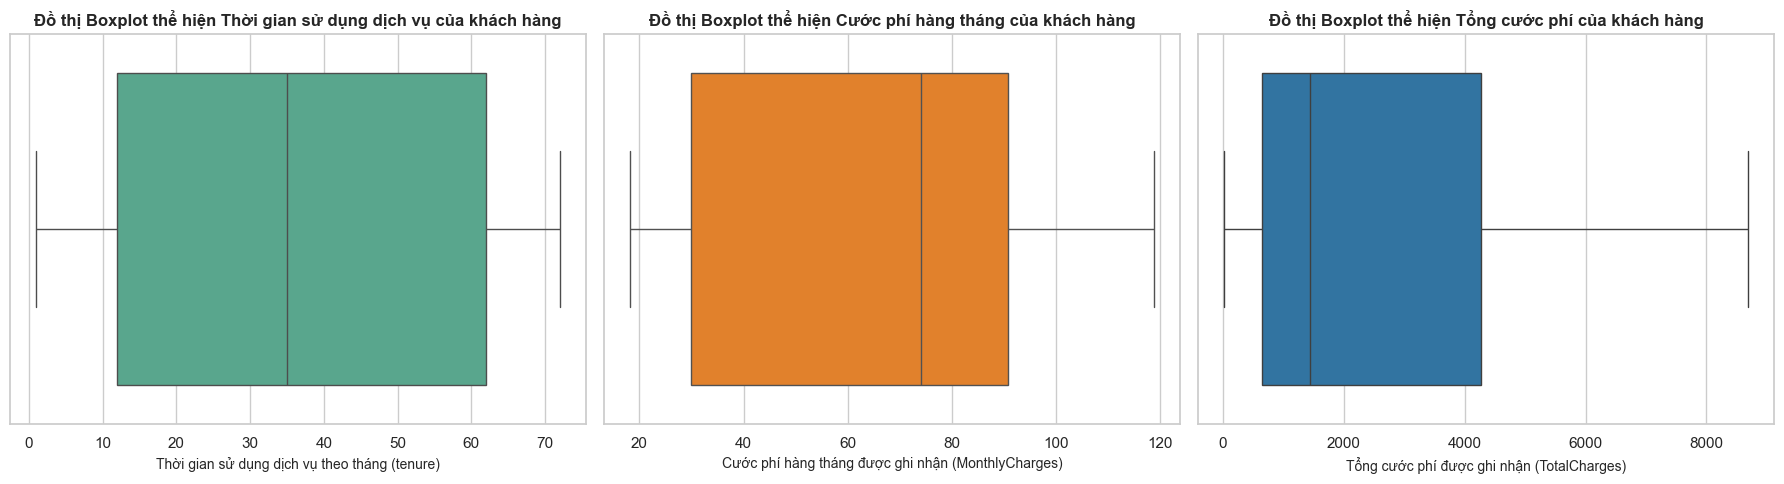

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_train_copy, x='tenure', color='#4CB391', ax=axes[0])
axes[0].set_title(f'Đồ thị Boxplot thể hiện {get_name("tenure")} của khách hàng', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Thời gian sử dụng dịch vụ theo tháng (tenure)', fontsize=10)

sns.boxplot(data=df_train_copy, x='MonthlyCharges', color='#FF7F0E', ax=axes[1])
axes[1].set_title(f'Đồ thị Boxplot thể hiện {get_name("MonthlyCharges")} của khách hàng', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cước phí hàng tháng được ghi nhận (MonthlyCharges)', fontsize=10)

sns.boxplot(data=df_train_copy, x='TotalCharges', color='#1F77B4', ax=axes[2])
axes[2].set_title(f'Đồ thị Boxplot thể hiện {get_name("TotalCharges")} của khách hàng', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tổng cước phí được ghi nhận (TotalCharges)', fontsize=10)

plt.tight_layout()
plt.show()

**Nhận xét:** Bằng trực quan hóa, ta nhận thấy rằng tất cả quan sát đều nằm trong khoảng không có điểm ngoại lai **Non-outlier region** của cả ba biến định lượng `tenure`, `MonthlyCharges`, `TotalCharges`. Điều này được thể hiện rõ hơn thông qua hàm dưới đây.

**Note:** Hàm thực hiện tìm khoảng phạm vi dữ liệu hợp lệ **Valid Data Range**, sau đó đếm số điểm ngoại lai ứng với từng biến.

In [106]:
def detect_outliers_bounds(columns):
    for col in columns:
        Q1 = df_train_copy[col].quantile(0.25)
        Q3 = df_train_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_count = ((df_train_copy[col] < lower_bound) | (df_train_copy[col] > upper_bound)).sum()

        print(f"Số điểm ngoại lai ứng với đặc trưng {get_name(col)} ({col}): {outliers_count} điểm.\n")

**Note:** Gọi lại hàm để kiểm tra điểm ngoại lai cho cả **3** đặc trưng định lượng.

In [107]:
detect_outliers_bounds(['tenure', 'MonthlyCharges', 'TotalCharges'])

Số điểm ngoại lai ứng với đặc trưng Thời gian sử dụng dịch vụ (tenure): 0 điểm.

Số điểm ngoại lai ứng với đặc trưng Cước phí hàng tháng (MonthlyCharges): 0 điểm.

Số điểm ngoại lai ứng với đặc trưng Tổng cước phí (TotalCharges): 0 điểm.



**Nhận xét:** Qua các bước kiểm định chéo, cả ba đặc trưng định lượng `tenure`, `MonthlyCharges` và `TotalCharges` không chỉ đảm bảo tính hợp lệ tuyệt đối về mặt toán học và logic nghiệp vụ, mà còn thể hiện phân phối tự nhiên không chứa điểm ngoại lai **outliers**; do đó, mọi kỹ thuật can thiệp dữ liệu, chẳng hạn như **imputation**, **dropping** hay **capping** đều được lược bỏ để bảo toàn thông tin gốc cho mô hình.

## 3.3 Kiểm tra tính hợp lệ biến định tính (Categorical Features Sanity Check)

**Note:** Mục tiêu của phần này là rà soát tính nhất quán và logic phân lớp của các biến định tính, đặc biệt tập trung vào mối liên hệ hệ thống giữa dịch vụ cốt lõi và các dịch vụ bổ trợ, nhằm triệt tiêu hoàn toàn các mâu thuẫn dữ liệu trước khi tiến hành mã hóa **Encoding**.

**Note:** Hàm được sử dụng để rà soát lỗi logic chéo giữa các nhóm biến định tính có liên hệ mật thiết với nhau:
   - Nhóm dịch vụ Internet: Kiểm tra mâu thuẫn giữa biến `InternetService` và các dịch vụ đi kèm `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, chẳng hạn như các dịch vụ đi kèm lại hiển thị *Yes* trong khi trạng thái lại là *No Internet*.
   - Nhóm dịch vụ Điện thoại: Kiểm tra mâu thuẫn tương tự giữa `PhoneService` và `MultipleLines`.

In [108]:
internet_dependent_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection","TechSupport", "StreamingTV", "StreamingMovies"]
phone_dependent_cols = ["MultipleLines"]

checks = {
        "Sử dụng dịch vụ internet nhưng không có internet": int(
            df_train_copy.loc[df_train_copy["InternetService"].eq("No"), internet_dependent_cols]
            .ne("No internet service").any(axis=1).sum()
        ),
        "Sử dụng internet nhưng không có dịch vụ internet": int(
            df_train_copy.loc[~df_train_copy["InternetService"].eq("No"), internet_dependent_cols]
            .eq("No internet service").any(axis=1).sum()
        ),
        "Sử dụng dịch vụ điện thoại nhưng không có điện thoại": int(
            df_train_copy.loc[df_train_copy["PhoneService"].eq("No"), phone_dependent_cols]
            .ne("No phone service").any(axis=1).sum()
        ),
         "Sử dụng điện thoại nhưng không có dịch vụ điện thoại": int(
            df_train_copy.loc[df_train_copy["PhoneService"].eq("Yes"), phone_dependent_cols]
            .eq("No phone service").any(axis=1).sum()
        ),
        "Không đăng ký bất kỳ dịch vụ nào": int(
            (df_train_copy["PhoneService"].eq("No") & df_train_copy["InternetService"].eq("No")).sum()
        ),
       
    }
    
print("--- Kiểm tra đặc trưng định tính ---")
display(pd.Series(checks).to_frame("Số lỗi phát hiện tương ứng"))

--- Kiểm tra đặc trưng định tính ---


,Số lỗi phát hiện tương ứng
Sử dụng dịch vụ internet nhưng không có internet,0
Sử dụng internet nhưng không có dịch vụ internet,0
Sử dụng dịch vụ điện thoại nhưng không có điện thoại,0
Sử dụng điện thoại nhưng không có dịch vụ điện thoại,0
Không đăng ký bất kỳ dịch vụ nào,7


**Note:**  
Trong quá trình rà soát chéo các dịch vụ cốt lõi, phát hiện một nhóm nhỏ gồm **7** khách hàng có trạng thái hoàn toàn vô lý: `PhoneService` = 'No' đồng thời `InternetService` = 'No'. Dưới góc độ nghiệp vụ viễn thông, việc một tài khoản đang hoạt động nhưng không sử dụng bất kỳ hạ tầng kết nối cơ bản nào là một điểm bất thường nghiêm trọng. Do số lượng vô cùng nhỏ với ít hơn **0.1%** tập dữ liệu, thực hiện loại bỏ **drop** **7** quan sát này để đảm bảo độ tinh khiết cho dữ liệu huấn luyện, tránh gây nhiễu cho các thuật toán Machine Learning.  

**Note:** Lọc ra danh sách 7 khách hàng không dùng bất kỳ dịch vụ kết nối nào và hiển thị toàn bộ thông tin của họ.

In [109]:
ghost_customers = df_train_copy[(df_train_copy["PhoneService"] == "No") & (df_train_copy["InternetService"] == "No")]
display(ghost_customers)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
63922,63922,Female,No,Yes,No,72,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.2500,1466.7500,No
219372,219372,Female,No,Yes,Yes,2,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.9500,24.8000,No
436919,436919,Female,No,Yes,No,72,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.9500,1429.6500,No
445299,445299,Male,No,No,No,1,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,19.1000,19.1000,No
552820,552820,Male,No,Yes,Yes,53,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.7000,1001.5000,No
558760,558760,Female,No,No,No,29,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.6500,672.7000,No
562266,562266,Male,No,Yes,Yes,71,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),35.8000,1573.8000,No


**Note:** Thực hiện loại bỏ **7 khách hàng ma** này và kiểm tra thông qua số lượng dòng sau khi **drop**

In [110]:
print(f"Số dòng ban đầu: {df_train_copy.shape[0]}")
df_train_copy = df_train_copy.drop(ghost_customers.index)
df_train_copy = df_train_copy.reset_index(drop=True)
print(f"Số dòng sau khi làm sạch: {df_train_copy.shape[0]}")

Số dòng ban đầu: 594194
Số dòng sau khi làm sạch: 594187


**Nhận xét:** 
- Sau khi loại bỏ các giá trị vô lí, là **7 khách hàng ma** không sử dụng bất kì dịch vụ kết nối nào, tập dữ liệu hiện tại đã đạt độ đồng bộ logic tuyệt đối. Các trường hợp mâu thuẫn vô lý như khách hàng không đăng ký Internet nhưng lại được ghi nhận có dùng `OnlineSecurity` không còn tồn tại.
- Nhờ nền tảng logic chặt chẽ này, việc viết thêm các hàm xử lý ngoại lệ hay gán lại nhãn **imputation** để ép buộc sự đồng nhất giữa các cột dịch vụ là không cần thiết.
- Sự trùng khớp hoàn hảo giữa các nhóm **No internet service / No phone service** với tình trạng sử dụng dịch vụ là điều kiện lý tưởng để thực hiện mã hóa **One-Hot Encoding**. Việc tạo các siêu cờ **Combo flags** không gặp rủi ro nhiễu hay lệch tín hiệu do mâu thuẫn nội tại của dữ liệu.

# 4. Phân tích Đơn biến: Khảo sát đặc trưng (Univariate Analysis)

## 4.1 Biến định lượng (Numerical Features)

**Note:** Việc thực hiện phân tích đơn biến đối với nhóm biến định lượng nhằm:

- Đánh giá hình dáng phân phối và các thông số về độ lệch, phương sai để thấu hiểu đặc tính thống kê nguyên bản của dữ liệu.
- Thông qua số lượng giá trị phân biệt và đồ thị trực quan để xác định chiến lược chuẩn hóa hoặc biến đổi dữ liệu **Data Transformation** phù hợp trước khi đưa vào huấn luyện.

**Note:** Phân tích tổng quan phân bố các biến định lượng.

In [111]:
variance = numerical_data.var()
skewness = numerical_data.skew()
unique_counts = numerical_data.nunique()

summary_table = pd.DataFrame({
    'Variance (Phương sai)': variance,
    'Skewness (Độ lệch)': skewness,
    'Nunique (Số giá trị phân biệt)': unique_counts
}).T

display(summary_table)

,tenure,MonthlyCharges,TotalCharges
Variance (Phương sai),628.0999,965.1861,5540923.8793
Skewness (Độ lệch),0.0631,-0.2895,0.9092
Nunique (Số giá trị phân biệt),72.0000,1921.0000,31910.0000


**Nhận xét:**
- Biến `tenture` chỉ thời gian sử dụng dịch vụ, tính theo tháng, là các giá trị nguyên dương nên chỉ phân bố trong khoảng nhỏ xác định.
- Biến `MonthlyCharges`, `TotalCharges` là cước phí theo tháng và tổng cước phí nên phân bố rất rộng, và là nguồn dữ liệu quý giá để tìm ra quy luật đặc trưng khi huấn luyện mô hình. 

**Note:** Trực quan hóa các biến định lượng bằng đồ thị Histogram để quan sát phân bố.

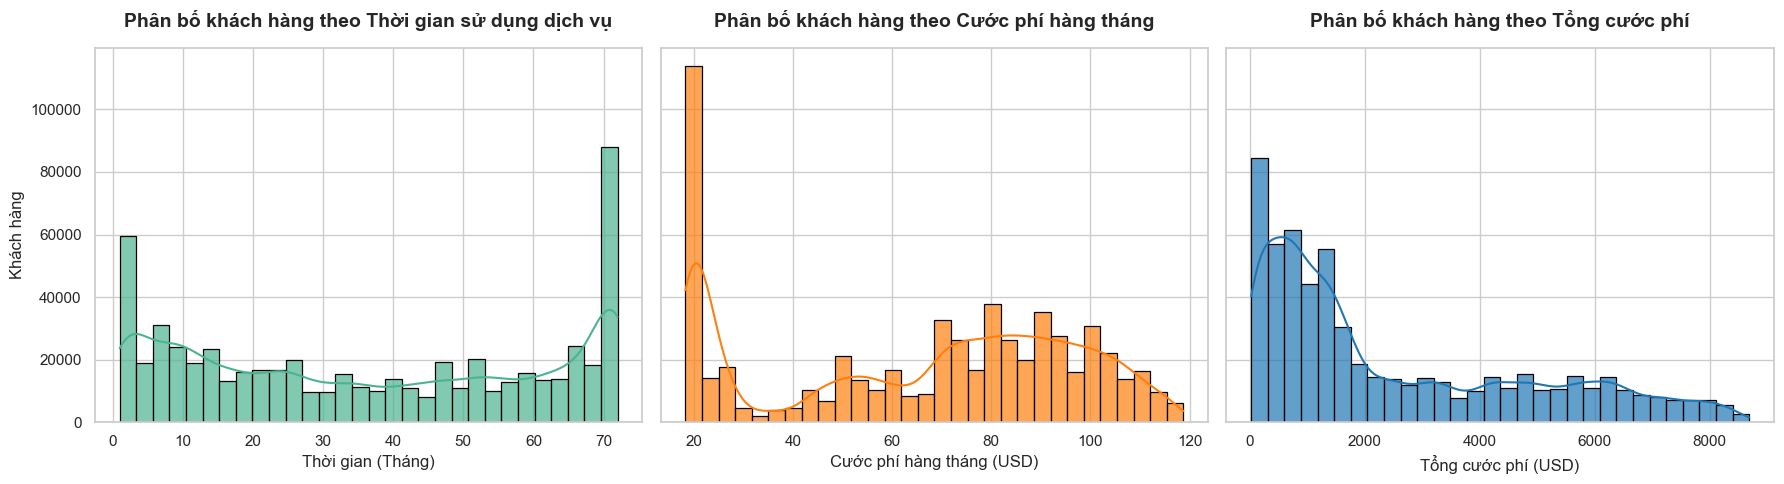

In [112]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5),sharey=True)
colors = ['#4CB391', '#FF7F0E', '#1F77B4'] 

for i, col in enumerate(numerical_features):
    sns.histplot(
    data=df_train_copy, 
    x=col, 
    ax=axes[i], 
    bins=30, 
    kde=True, 
    color=colors[i], 
    edgecolor='black', 
    alpha=0.7,
    kde_kws={'cut': 0, 'bw_adjust': 1.5} 
)
    
    axes[i].set_title(f'Phân bố khách hàng theo {get_name(col)}', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_ylabel('Khách hàng' if i == 0 else '', fontsize=12)
axes[0].set_xlabel('Thời gian (Tháng)', fontsize=12)
axes[1].set_xlabel('Cước phí hàng tháng (USD)',fontsize=12)
axes[2].set_xlabel('Tổng cước phí (USD)',fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:**
-  Thời gian gắn bó `tenure`: Dữ liệu có dạng phân phối hai đỉnh **Bimodal Distribution**. Khách hàng tập trung với mật độ rất cao ở hai biên, gồm nhóm khách hàng mới với thời gian sử dụng dịch vụ dưới **6** tháng và nhóm khách hàng lâu năm, từ **60** tháng trở lên. Giữa hai đỉnh khách hàng phân bố tương đối đều.
- Cước phí hàng tháng `MonthlyCharges`: Dữ liệu ghi nhận một đỉnh nhọn cô lập mang giá trị rất cao ở mức phí thấp nhất, khoảng **20$**, cho thấy lượng lớn khách hàng chỉ sử dụng gói dịch vụ cơ bản nhất. Phân đoạn còn lại trải dài từ **40$** đến **115$** với các đỉnh nhỏ nhấp nhô nhưng không có mức cước nào quá áp đảo.
- Tổng cước phí `TotalCharges`: Phân phối có dạng lệch phải mạnh **Right-skewed**. Đa số khách hàng có tổng mức chi tiêu tích lũy thấp, tập trung dày đặc ở vùng sát biên trái **0-2000$** và giảm dần với phần đuôi kéo dài đến hơn **8000$**. Điều này hoàn toàn hợp lý, bởi nhóm khách hàng mới và nhóm dùng gói cước cơ bản chiếm tỷ trọng lớn, trực tiếp kéo tổng cước phí tích lũy của họ xuống mức thấp.

**Kết luận:** 
- Dựa trên hình dạng phân phối, ta có thể chia `tenure` thành **3** nhóm  tương ứng với **3** khoảng thời gian gắn bó: *Khách hàng mới từ 1 - 6 tháng*, *Khách hàng tiêu chuẩn từ 7 - 48 tháng, và *Khách hàng lâu năm, gắn bó trên 48 tháng*. Vì các nhóm này mang ý nghĩa thứ bậc rõ ràng, phương pháp Mã hóa thứ tự **Ordinal Encoding** nên được ưu tiên để giữ lại đặc trưng này.
- Do các biến định lượng gốc có sự chênh lệch lớn về biên độ, `MonthlyCharges` ở mức hàng chục trong khi `TotalCharges` lên đến hàng nghìn, việc áp dụng các kỹ thuật chuẩn hóa như **Min-Max Scaler** hoặc **Standard Scaler** là bắt buộc nhằm tránh sai lệch trọng số cho các mô hình nhạy cảm với khoảng cách như **KNN** hay **SVM**.
- Phân bố của `TotalCharges` bị lệch phải mạnh **Right-skewed**, tuy nhiên đồ thị Boxplot cho thấy dữ liệu không xuất hiện các giá trị ngoại lai bất thường. Để xử lý dạng phân phối lệch này cho các mô hình tuyến tính như Logistic Regression, ta có thể cân nhắc giữa kỹ thuật Biến đổi Logarit **Log Transformation** hoặc thực hiện Rời rạc hóa **Binning** thành các nhóm khoảng chi tiêu nhằm làm mượt dữ liệu một cách hiệu quả.

## 4.2 Biến định tính (Categorical Features)

**Note:** Việc phân nhóm và khảo sát các biến định tính nhằm xác định không gian mẫu, từ đó xác định độ phân nhánh và cấu trúc phân bố của từng thuộc tính. Bước này giúp ta phát hiện các đặc trưng bị mất cân bằng nghiêm trọng hoặc có nhãn hiếm, làm cơ sở để xây dựng chiến lược mã hóa **Encoding** và chuẩn bị dữ liệu phù hợp cho mô hình.

**Note:** Hàm đổi tên biến, sử dụng cho mục đích hiển thị.

In [113]:
config_features = {
    'gender': {'name': 'Giới tính', 'order': ['Male', 'Female']},
    'SeniorCitizen': {'name': 'Tiêu chí người cao tuổi', 'order': ['Yes', 'No']},
    'Partner': {'name': 'Tiêu chí bạn đời', 'order': ['Yes', 'No']},
    'Dependents': {'name': 'Tiêu chí người chăm sóc', 'order': ['Yes', 'No']},
    'PhoneService': {'name': 'Dịch vụ điện thoại', 'order': ['Yes', 'No']},
    'PaperlessBilling': {'name': 'Dịch vụ hóa đơn điện tử', 'order': ['Yes', 'No']},
    'MultipleLines': {'name': 'Dịch vụ đa tuyến', 'order': ['Yes', 'No', 'No phone service']},
    'OnlineSecurity': {'name': 'Dịch vụ bảo mật trực tuyến', 'order': ['Yes', 'No', 'No internet service']},
    'OnlineBackup': {'name': 'Dịch vụ sao lưu trực tuyến', 'order': ['Yes', 'No', 'No internet service']},
    'DeviceProtection': {'name': 'Dịch vụ bảo hiểm thiết bị', 'order': ['Yes', 'No', 'No internet service']},
    'TechSupport': {'name': 'Dịch vụ hỗ trợ kỹ thuật', 'order': ['Yes', 'No', 'No internet service']},
    'StreamingTV': {'name': 'Dịch vụ truyền hình trực tuyến', 'order': ['Yes', 'No', 'No internet service']},
    'StreamingMovies': {'name': 'Dịch vụ xem phim trực tuyến', 'order': ['Yes', 'No', 'No internet service']},

    'InternetService': {'name': 'Loại dịch vụ Internet', 'order': None},
    'Contract': {'name': 'Loại hợp đồng', 'order': None},
    'PaymentMethod': {'name': 'Phương thức thanh toán', 'order': None}
}

**Note:** Trực quan hóa phân bố khách hàng theo các đặc trưng định tính.

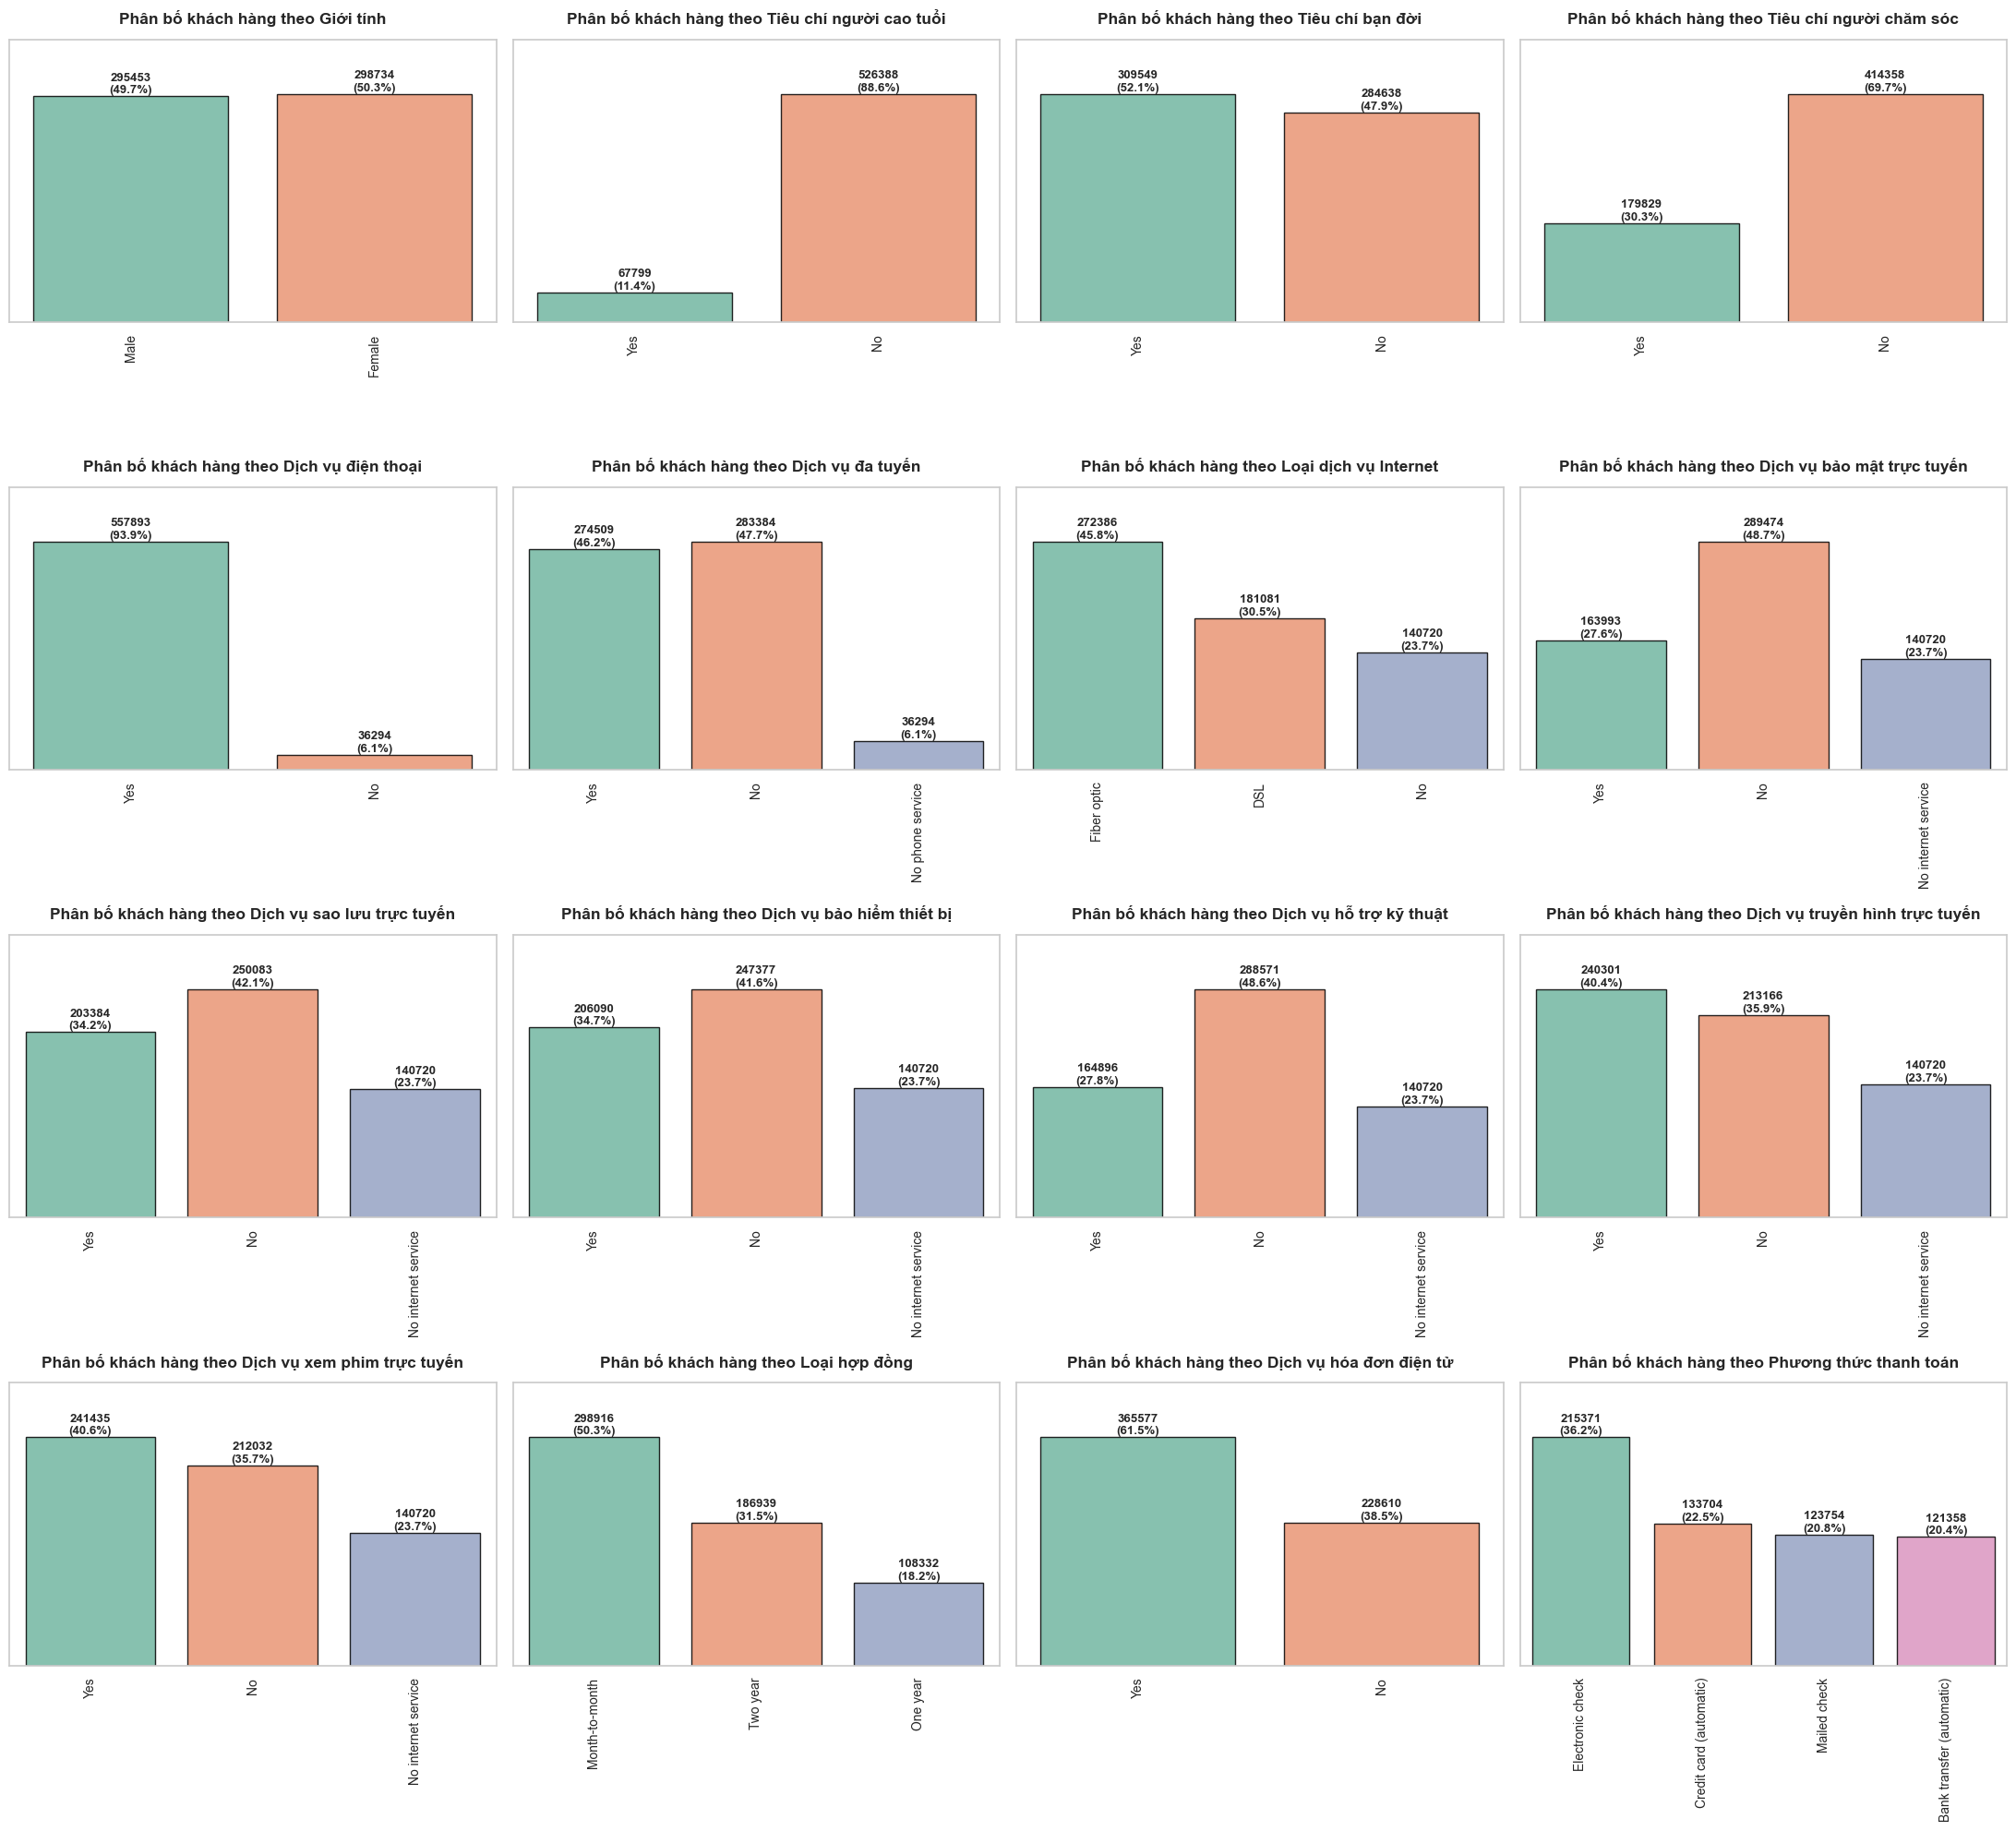

In [114]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(22, 20))
axes = axes.flatten()

custom_palette = sns.color_palette('Set2', 4)

for i, col in enumerate(categorical_features):
    if col not in config_features:
        continue
        
    feature_info = config_features[col]
    ten = feature_info['name']


    if feature_info['order'] is not None:
        category_order = feature_info['order']
    else:
        category_order = df_train_copy[col].value_counts().index.tolist()
    
    color_mapping = {label: custom_palette[idx] for idx, label in enumerate(category_order)}
    
    sns.countplot(
        data=df_train_copy, 
        x=col, 
        order=category_order,
        hue_order=category_order,
        hue=col,
        ax=axes[i], 
        palette=color_mapping,
        edgecolor='black',
        alpha=0.85,
        legend=False
    )

    total = len(df_train_copy[col])
    for p in axes[i].patches:
        height = p.get_height()
        pct = height / total * 100
        y_position = height + (total * 0.01)
        axes[i].annotate(
            f'{int(height)}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9.5, fontweight='bold'
        )
    
    ymax = axes[i].get_ylim()[1]
    axes[i].set_ylim(0, ymax * 1.18)
    
    axes[i].set_title(f'Phân bố khách hàng theo {ten}', fontsize=12.5, fontweight='bold', pad=12)
    
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_yticks([])
    axes[i].set_yticklabels([])
    

    axes[i].tick_params(axis='x', rotation=90, labelsize=10)

plt.tight_layout()
plt.show()

In [115]:
rows = []
for i, col in enumerate(categorical_features, start=1):
    counts = df_train_copy[col].value_counts(dropna=False)
    ten_tieng_viet = config_features[col]['name']
    rows.append({
        "STT": i,
        "Đặc trưng gốc (Feature)": col,
        "Ý nghĩa đặc trưng":ten_tieng_viet,
        "Số giá trị phân biệt": df_train_copy[col].nunique(dropna=False),
        "Giá trị áp đảo": counts.index[0],
        "Tỷ lệ tương ứng": counts.iloc[0] / len(df_train_copy) * 100,
        "Số giá trị hiếm (< 1%)": int((counts / len(df_train_copy) < 0.01).sum()),
    })

cat_summary = pd.DataFrame(rows)

display(cat_summary.style.format({'Tỷ lệ tương ứng': '{:.2f}%'}).hide(axis="index"))

STT,Đặc trưng gốc (Feature),Ý nghĩa đặc trưng,Số giá trị phân biệt,Giá trị áp đảo,Tỷ lệ tương ứng,Số giá trị hiếm (< 1%)
1,gender,Giới tính,2,Female,50.28%,0
2,SeniorCitizen,Tiêu chí người cao tuổi,2,No,88.59%,0
3,Partner,Tiêu chí bạn đời,2,Yes,52.10%,0
4,Dependents,Tiêu chí người chăm sóc,2,No,69.74%,0
5,PhoneService,Dịch vụ điện thoại,2,Yes,93.89%,0
6,MultipleLines,Dịch vụ đa tuyến,3,No,47.69%,0
7,InternetService,Loại dịch vụ Internet,3,Fiber optic,45.84%,0
8,OnlineSecurity,Dịch vụ bảo mật trực tuyến,3,No,48.72%,0
9,OnlineBackup,Dịch vụ sao lưu trực tuyến,3,No,42.09%,0
10,DeviceProtection,Dịch vụ bảo hiểm thiết bị,3,No,41.63%,0


**Nhận xét:**
- Tập dữ liệu có tính phân nhánh thấp khá đồng đều. Phần lớn các biến định tính chỉ xoay quanh **2** đến **3** giá trị phân biệt, biến phức tạp nhất `PaymentMethod` cũng chỉ dừng lại ở **4** nhãn.
- Không xuất hiện tình trạng nhãn hiếm **Rare Labels**. Tất cả các nhóm giá trị trong từng biến đều chiếm tỷ trọng đáng kể với mức thấp nhất vẫn đạt trên **6.1%** như ở `PhoneService` và `MultipleLines`, không có nhóm nào rơi vào vùng nguy hiểm dưới **1%**.
- `PhoneService` có sự phân hóa thấp nhất khi nhãn *Yes* chiếm ưu thế tuyệt đối lên tới **93.89%**, theo đó lượng khách hàng không sử dụng điện thoại chỉ chiếm một phần rất nhỏ **6.1%**.
- Các nhóm biến dịch vụ gia tăng như `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` và đặc trưng gốc `InternetService` đều mang cùng một đặc điểm: Nhóm khách hàng không đăng ký internet *No internet service* luôn chiếm một tỷ lệ cố định là **23.7%**, tương đương **140,727** dòng. Điều tương tự cũng xảy ra với `MultipleLines` và đặc trưng gốc `PhoneService` khi nhóm khách hàng đăng kí dịch vụ điện thoại cũng chiếm một tỷ lệ cố định là **6.1%**, tương đương **36301** dòng. Ta có thể thực hiện phân nhóm các biến này để tìm ra quy luật ẩn về sự rời bỏ dịch vụ của khách hàng.

**Kết luận:**
- Do toàn bộ các đặc trưng đều có độ phân nhánh thấp, phương pháp **One-Hot Encoding** sẽ được áp dụng đồng loạt để số hóa dữ liệu. Cấu trúc này đảm bảo mô hình học máy hiểu đúng các nhãn phân loại mà hoàn toàn không lo rủi ro bùng nổ chiều dữ liệu **Curse of Dimensionality**.
- Mặc dù nhóm khách hàng *No internet service* chiếm tỷ lệ cố định **23.7%** ở các biến dịch vụ đi kèm và tương tự với *No phone service* chiếm **6.1%**, ta quyết định giữ nguyên những nhãn này thay vì gộp chung vào nhóm *No*, nhằm phục vụ cho phân tích **Risk Gap** và đo lường tỷ lệ giữ chân khách hàng nâng cao ở các bước sau, giúp làm rõ sự khác biệt về hành vi rời bỏ dịch vụ.
- Dựa trên quan sát về các biến dịch vụ đi kèm, nhãn *No internet service* hoàn toàn có thể được gộp chung vào nhãn "No" mà không làm mất mát thông tin. Việc này giúp giảm số lượng cột sau khi mã hóa **One-Hot Encoding** xuống còn một nửa đối với các biến này, giúp tập dữ liệu gọn gàng hơn.
- `PhoneService` có độ phân hóa rất thấp khi **93.89%** mẫu dữ liệu rơi vào nhóm *Yes*. Sự mất cân bằng nghiêm trọng này khiến biến số mang tính nhiễu cao và không đóng góp đáng kể vào khả năng dự báo của mô hình.

## 4.3 Phân bố biến mục tiêu (Target Variable - `Churn`)

**Note:** Việc thực hiện phân tích sơ bộ hành vi khách hàng nhằm
- Đánh giá tỷ lệ phân bố giữa nhóm khách hàng tiếp tục sử dụng *No* và nhóm rời bỏ dịch vụ *Yes* nhằm xác định mức độ mất cân bằng dữ liệu **Imbalanced Data**.
- Thông qua các đánh giá để xác định chiến lược phân tách tập mẫu và lựa chọn thước đo đánh giá mô hình **Evaluation Metric** phù hợp.

**Note:** Trực quan hóa tỷ lệ khách hàng rời bỏ dịch vụ bằng Biểu đồ Cột, nhằm phản ánh thực tế sự mất cân bằng dữ liệu và tỷ lệ mất cân bằng dữ liệu.

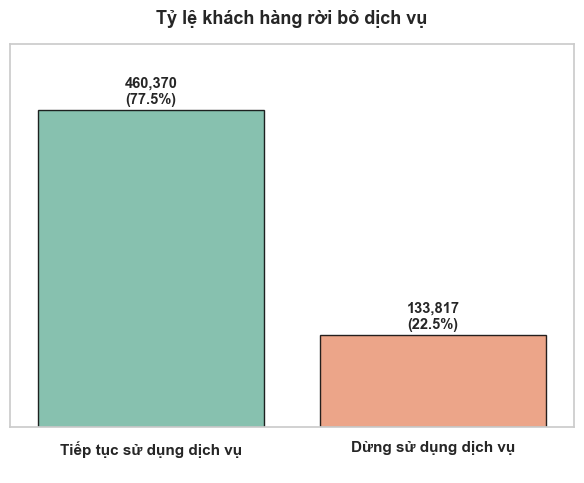

In [142]:
fig, ax = plt.subplots(figsize=(6, 5))
churn_counts = df_train_copy['Churn'].value_counts()
total = len(df_train_copy)

labels_vn = {'No': 'Tiếp tục sử dụng dịch vụ\n', 'Yes': 'Dừng sử dụng dịch vụ\n'}
category_order = ['No', 'Yes']

custom_palette = sns.color_palette('Set2', 2)
color_mapping = {label: custom_palette[idx] for idx, label in enumerate(category_order)}

sns.countplot(
    data=df_train_copy,
    x='Churn',
    order=category_order,
    hue_order=category_order,
    hue='Churn',
    ax=ax,
    palette=color_mapping,
    edgecolor='black',
    alpha=0.85,
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    pct = height / total * 100
    y_position = height + (total * 0.01)
    ax.annotate(
            f'{int(height):,}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2., y_position),
            ha='center', va='bottom',
            fontsize=10.5, fontweight='bold'
        )

ymax = ax.get_ylim()[1]
ax.set_ylim(0, ymax * 1.15)

ax.set_title('Tỷ lệ khách hàng rời bỏ dịch vụ', fontsize=13, fontweight='bold', pad=15)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_xticks(range(len(category_order)))
ax.set_xticklabels([labels_vn[label] for label in category_order], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:** 
- Tập dữ liệu phân bố không đồng đều và thể hiện sự mất cân bằng mẫu ở mức độ vừa phải với tỷ lệ xấp xỉ **3.5 : 1**.
- Nhóm khách hàng tiếp tục sử dụng dịch vụ chiếm ưu thế tuyệt đối với **77.5%**, tương đương **460,377** khách hàng.
- Nhóm khách hàng rời bỏ dịch vụ — nhóm mục tiêu cốt lõi cần dự đoán — chiếm phần thiểu số với tỷ lệ **22.5%**, tương đương **133,817** khách hàng.

**Kết luận:**
- Chiến lược phân tách tập mẫu: Áp dụng bắt buộc kỹ thuật phân tầng **Stratified Sampling** như **Stratified K-Fold** hoặc **Stratified Shuffle Split** trong suốt quá trình chia tập Train/Validation/Test. Phương pháp này đảm bảo tỷ lệ cấu trúc **22.5\%** của nhóm *Yes* được giữ nguyên vẹn trên mọi nếp gấp **fold**, tránh hiện tượng sai lệch phân phối giữa các tập dữ liệu.
- Lựa chọn thước đo đánh giá: Loại bỏ hoàn toàn tỷ lệ dự đoán đúng **Accuracy** ra khỏi danh sách thước đo chính để tránh bẫy tối ưu sai lệch.Sử dụng **F1-Score** và **Precision-Recall AUC** làm các thước đo quyết định để đánh giá trực tiếp khả năng nhận diện nhóm khách hàng rời bỏ dịch vụ, kết hợp với **ROC-AUC** để đo lường năng lực phân tách rủi ro tổng thể của mô hình.
- Định hướng thuật toán: Nhằm ngăn chặn việc các mô hình học máy bị thiên lệch **bias** về phía nhóm đa số, ở giai đoạn huấn luyện cần kích hoạt các tham số phạt thực thể thuộc nhóm thiểu số trong hàm mất mát, chẳng hạn như cấu hình **scale_pos_weight** trong **XGBoost** hoặc **class_weight='balanced'** trong **Random Forest/Logistic Regression**.

# 5. Phân tích Song biến: Động cơ rời bỏ (Bivariate Analysis)

## 5.1 Phân tích nhóm biến định lượng (Numerical Features vs Target)

**Note:** Gán nhãn cho `Churn`, sử dụng cho mục đích hiển thị

In [117]:
churn_labels = {"No": "Tiếp tục sử dụng", "Yes": "Dừng sử dụng"}

**Note:** Thực hiện trực quan hóa phân phối của các biến định lượng gốc tích hợp thuộc tính `Churn` bằng cặp Đồ thị phân phối **Histplot/KDE** và Biểu đồ hộp **Boxplot**, nhằm
- Đánh giá hình dáng phân phối và sự dịch chuyển trọng tâm dữ liệu giữa *Nhóm khách hàng tiếp tục sử dụng Dịch vụ* và *Nhóm khách hàng dừng sử dụng dịch vụ*.
- Phát hiện các điểm gãy phân phối, các ngưỡng giá trị tới hạn và hành vi phi tuyến tính để làm cơ sở vững chắc cho các quyết định **Feature Engineering** như phân nhóm, tạo cờ cảnh báo hoặc biến đổi tỷ lệ ở bước tiếp theo.

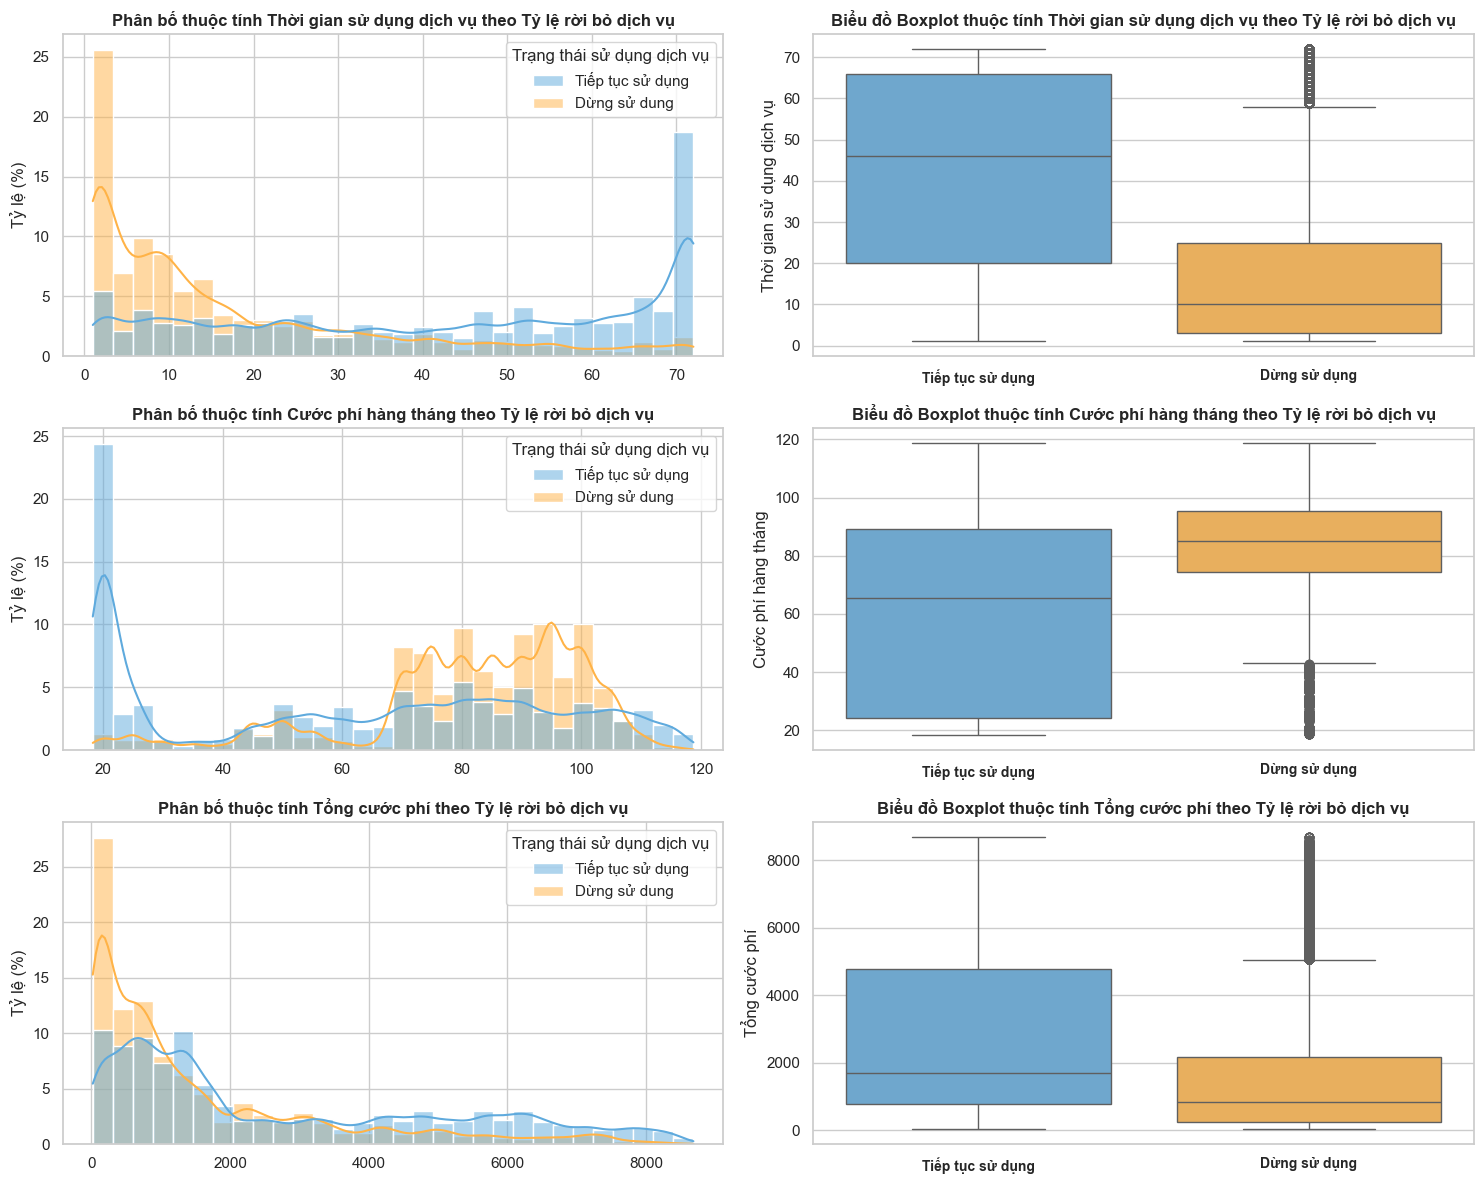

In [144]:
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(15, 4 * len(numerical_features)))

churn_palette = {"Yes": "#FFB347", "No": "#5FAADD"} 

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df_train_copy, 
        x=col, 
        hue="Churn",
        hue_order=["No", "Yes"], 
        kde=True, 
        bins=30,
        stat="percent", 
        common_norm=False,
        palette=churn_palette,
        ax=axes[i, 0],
        legend = True
    )
    axes[i, 0].set_title(f"Phân bố thuộc tính {get_name(col)} theo Tỷ lệ rời bỏ dịch vụ", fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel("Tỷ lệ (%)")
    axes[i, 0].set_xlabel("")

    if axes[i, 0].get_legend():
        axes[i, 0].get_legend().set_title("Trạng thái sử dụng dịch vụ")
        for text, label in zip(axes[i, 0].get_legend().get_texts(), ['Tiếp tục sử dụng', 'Dừng sử dung']):
            text.set_text(label)

    sns.boxplot(
        data=df_train_copy, 
        x="Churn", 
        y=col, 
        hue="Churn",
        order=["No","Yes"],
        legend=False,
        palette=churn_palette,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"Biểu đồ Boxplot thuộc tính {get_name(col)} theo Tỷ lệ rời bỏ dịch vụ", fontsize=12, fontweight='bold')
    
    axes[i, 1].set_ylabel(get_name(col))
    axes[i, 1].set_xlabel('')

    axes[i, 1].set_xticks([0,1])
    axes[i, 1].set_xticklabels([churn_labels["No"], churn_labels["Yes"]], fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:** 
- Thời gian gắn bó `tenure`: Xuất hiện hiện tượng phân tách rõ rệt về hành vi theo thời gian. Nhóm dừng sử dụng dịch vụ tập trung với mật độ cực kỳ cao trong giai đoạn trải nghiệm sớm từ **1** đến **6** tháng đầu tiên và giảm dần theo thời gian. Ngược lại, nhóm tiếp tục sử dụng dịch vụ chiếm ưu thế tuyệt đối tại các mốc khách hàng lâu năm, với thời gian gắn bó trên **48** tháng. Trung vị thời gian gắn bó của nhóm rời đi rất thấp, nằm ở khoảng **10** tháng.
- Cước phí hàng tháng `MonthlyCharges`: Khách hàng cực kỳ nhạy cảm về giá. Nhóm tiếp tục sử dụng dịch vụ tạo một đỉnh rất cao ở phân khúc giá rẻ quanh mốc **20$**. Ngược lại, nhóm rời bỏ chiếm tỷ lệ áp đảo ở phân khúc cước phí cao từ **70$** đến **105$**. Đồ thị Boxplot khẳng định nhóm dừng sử dụng dịch vụ có mức cước phí trung vị cao hơn hẳn nhóm tiếp tục gắn bó.
- Tổng chi phí `TotalCharges`: Cả hai nhóm đều có phân phối lệch phải **Right-Skewed**. Tuy nhiên, nhóm rời đi tích lũy mật độ cao quanh mốc $0$. Điều này hoàn toàn logic vì họ đã thực hiện hủy dịch vụ ngay từ những tháng đầu, dẫn đến tổng chi phí tích lũy chưa cao.

## 5.2 Phân tích nhóm biến định tính (Categorical Features vs Target)

**Note:** Việc thực hiện phân tích song biến **Bivariate Analysis** đối với nhóm đặc trưng định tính *Categorical Features* và biến mục tiêu `Churn` nhằm
- Đánh giá sự phân hóa tỷ lệ dừng sử dụng dịch vụ giữa các hạng mục khác nhau như loại hợp đồng, phương thức thanh toán,... nhằm định vị chính xác các phân khúc khách hàng mang rủi ro cao nhất.
- Khám phá các mẫu hành vi tiêu dùng dựa trên đặc tính dịch vụ, từ đó làm cơ sở khoa học để tinh chỉnh không gian mẫu **Category Grouping**, lựa chọn chiến lược mã hóa **Encoding** tối ưu.

**Note:** Gán cờ *flag* tương ứng cho biến **Churn**

In [119]:
df_train_copy = df_train_copy.assign(churn_flag=df_train_copy["Churn"].eq("Yes").astype(int))

**Note:** Thực hiện thiết lập bảng tính Mức độ phân hóa rủi ro **Risk Spread** cho nhóm biến định tính nhằm
- Đo lường một cách định lượng khoảng cách về tỷ lệ dừng sử dụng dịch vụ **Churn Rate Gap** giữa hai nhóm nhãn mang rủi ro cao nhất và thấp nhất trong cùng một đặc trưng.
- Sắp xếp và sàng lọc ra những biến định tính có sức mạnh phân loại và dự đoán mạnh nhất, định hướng trọng tâm cho các bước trực quan hóa.

In [120]:
rows = []
for col in categorical_features:
    grouped = df_train_copy.groupby(col, dropna=False)["churn_flag"].agg(churn_rate="mean", rows="size")
    grouped = grouped[grouped["rows"] >= 100]
    high = grouped.sort_values("churn_rate", ascending=False).iloc[0]
    low = grouped.sort_values("churn_rate", ascending=True).iloc[0]
    ten_tieng_viet = config_features[col]['name']
    rows.append({
        "Đặc trưng":             col,
        "Ý nghĩa đặc trưng": ten_tieng_viet,
        "Số giá trị phân biệt": df_train_copy[col].nunique(),
        "Giá trị mang rủi ro cao nhất":    high.name,
        "Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro cao nhất":  high["churn_rate"] * 100,
        "Tổng số khách hàng (nhóm rủi ro cao nhất)":         int(high["rows"]),
        "Giá trị mang rủi ro thấp nhất":   low.name,
        "Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro thấp nhất": low["churn_rate"] * 100,
        "Tổng số khách hàng (nhóm rủi ro thấp nhất)":        int(low["rows"]),
        "Mức độ phân hóa rủi ro":       (high["churn_rate"] - low["churn_rate"]) * 100,
    })

risk_spread = pd.DataFrame(rows).sort_values("Mức độ phân hóa rủi ro", ascending=False)
display(risk_spread.style.format({'Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro cao nhất': '{:.2f}%', 'Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro thấp nhất': '{:.2f}%', 'Mức độ phân hóa rủi ro': '{:.2f}%'}).hide(axis="index"))

Đặc trưng,Ý nghĩa đặc trưng,Số giá trị phân biệt,Giá trị mang rủi ro cao nhất,Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro cao nhất,Tổng số khách hàng (nhóm rủi ro cao nhất),Giá trị mang rủi ro thấp nhất,Tỷ lệ dừng sử dụng dịch vụ nhóm rủi ro thấp nhất,Tổng số khách hàng (nhóm rủi ro thấp nhất),Mức độ phân hóa rủi ro
PaymentMethod,Phương thức thanh toán,4,Electronic check,48.91%,215371,Credit card (automatic),6.93%,133704,41.97%
Contract,Loại hợp đồng,3,Month-to-month,42.05%,298916,Two year,1.00%,186939,41.06%
InternetService,Loại dịch vụ Internet,3,Fiber optic,41.54%,272386,No,1.43%,140720,40.11%
OnlineSecurity,Dịch vụ bảo mật trực tuyến,3,No,40.61%,289474,No internet service,1.43%,140720,39.18%
TechSupport,Dịch vụ hỗ trợ kỹ thuật,3,No,40.16%,288571,No internet service,1.43%,140720,38.73%
OnlineBackup,Dịch vụ sao lưu trực tuyến,3,No,39.10%,250083,No internet service,1.43%,140720,37.67%
DeviceProtection,Dịch vụ bảo hiểm thiết bị,3,No,38.06%,247377,No internet service,1.43%,140720,36.63%
SeniorCitizen,Tiêu chí người cao tuổi,2,Yes,50.03%,67799,No,18.98%,526388,31.05%
StreamingMovies,Dịch vụ xem phim trực tuyến,3,No,29.93%,212032,No internet service,1.43%,140720,28.50%
StreamingTV,Dịch vụ truyền hình trực tuyến,3,No,29.74%,213166,No internet service,1.43%,140720,28.31%


**Note:** Trực quan hóa các biến định tính có mức phân hóa rủi ro cao nhất

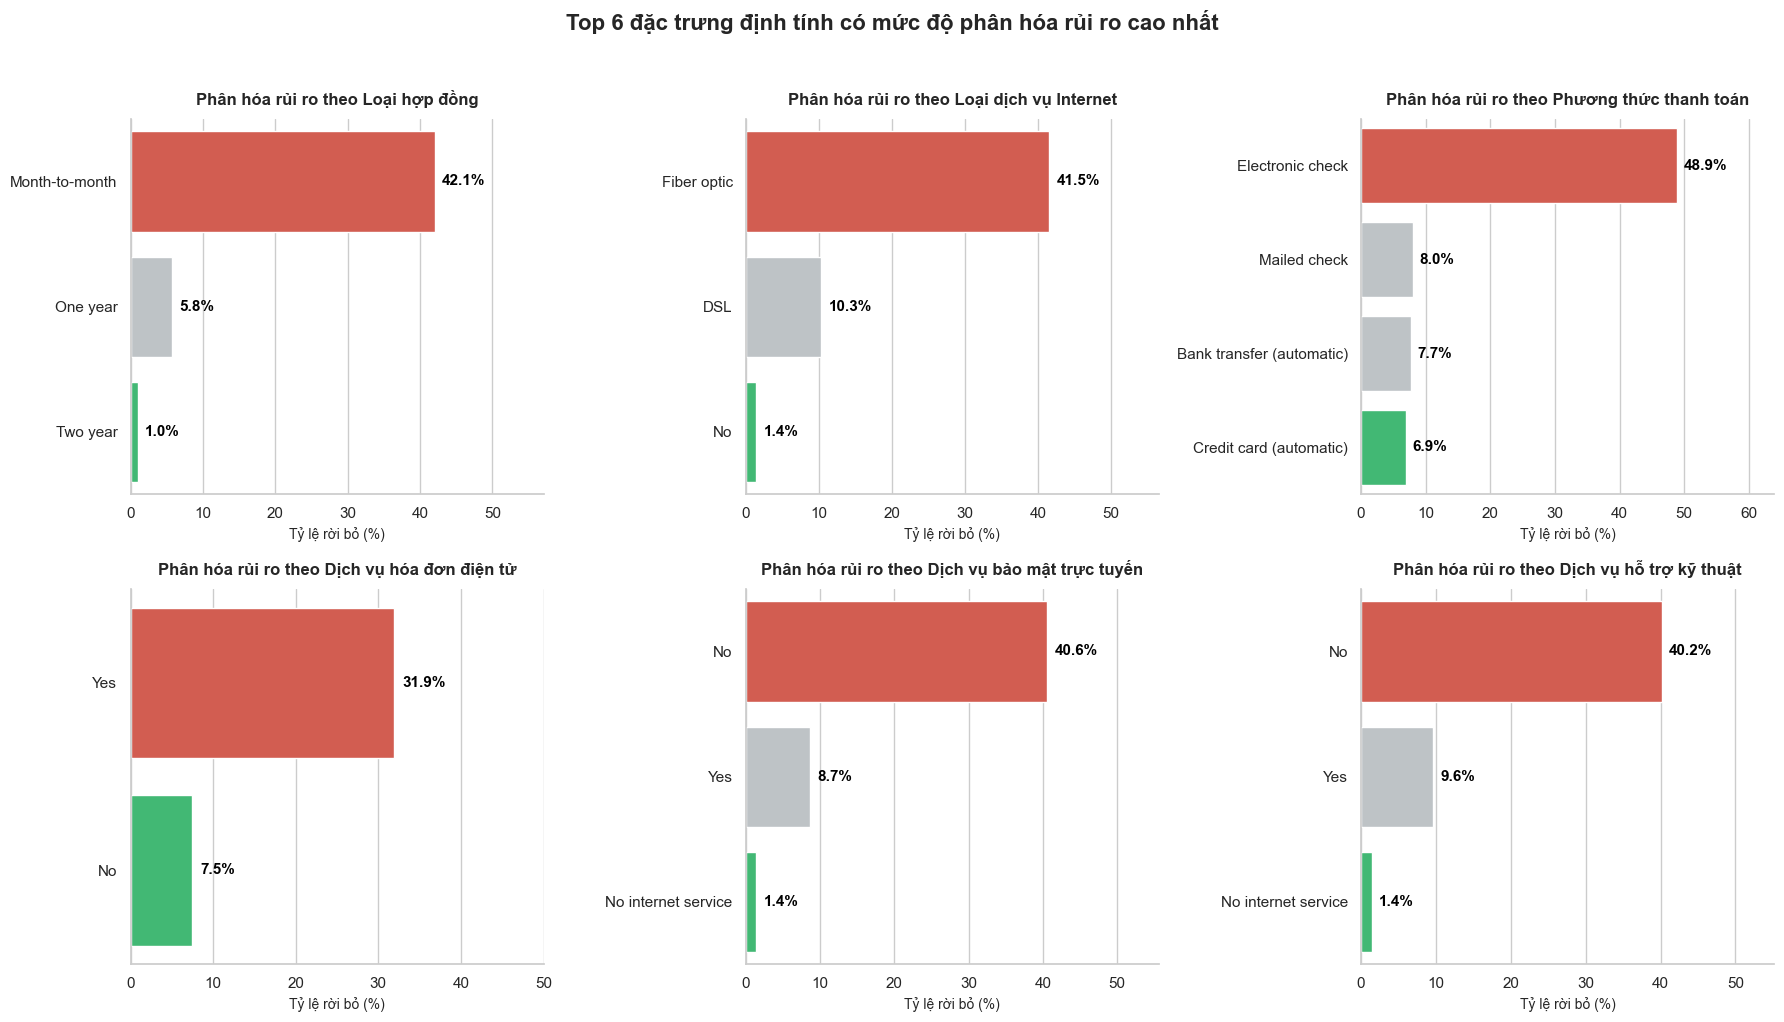

In [121]:
selected_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "OnlineSecurity",
    "TechSupport",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10)) 

fig.suptitle("Top 6 đặc trưng định tính có mức độ phân hóa rủi ro cao nhất", fontsize=16, fontweight='bold', y=1.02)
for ax, feature in zip(axes.ravel(), selected_features):
    plot_data = (
        df_train_copy.groupby(feature, dropna=False)["churn_flag"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index(name="churn_rate")
    )
    
    risk_palette = ["#E74C3C" if i == 0 else ("#2ECC71" if i == len(plot_data) - 1 else "#BDC3C7") for i in range(len(plot_data))]

    sns.barplot(
        data=plot_data, 
        y=feature, 
        x="churn_rate", 
        ax=ax,
        palette=risk_palette,
        hue=feature,
        legend=False
    )
    
    ten_tieng_viet = config_features.get(feature, {}).get('name', feature)
    ax.set_title(f"Phân hóa rủi ro theo {ten_tieng_viet}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Tỷ lệ rời bỏ (%)", fontsize=10)
    ax.set_ylabel("")

    ax.set_xlim(0, max(50, plot_data["churn_rate"].max() + 15)) 
    
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}%', 
                    (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', fontsize=11, color='black', fontweight='bold')

    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

**Nhận xét:** 
- Nhóm tính năng cốt lõi với khoảng phân hóa **>40%**: 
    * Phương thức thanh toán `PaymentMethod` sở hữu mức phân hóa mạnh nhất với tỷ lệ **41.97%**. Khách hàng sử dụng *Electronic check* có tỷ lệ rời bỏ dịch vụ chạm đỉnh với **48.91%**, trong khi nhóm thanh toán tự động qua thẻ tín dụng *Credit card automatic* cực kỳ gắn bó với tỷ lệ rời đi chỉ **6.93%**.
    * Loại hợp đồng `Contract` với biên độ phân hóa đạt **41.06%**. Khách hàng ký hợp đồng ngắn hạn *Month-to-month* mang rủi ro rất cao với tỷ lệ hủy dịch vụ đạt **42.05%**. Ngược lại, cam kết dài hạn **2** năm *Two year* gần như triệt tiêu nguy cơ rời đi khi tỷ lệ rời đi chỉ còn vỏn vẹn **1.00%**.
    * Loại dịch vụ Internet `InternetService` ghi nhận khoảng lệch **40.11%**. Nhóm sử dụng hạ tầng mạng cáp quang cao cấp *Fiber optic* lại mang tỷ lệ rời đi rất cao, lên đến **41.54%**.
- Nhóm rào cản hệ sinh thái & Nhân khẩu học với khoảng phân hóa **20%-40%**: 
    * Khách hàng không đăng ký các dịch vụ bổ trợ an toàn mạng như `OnlineSecurity` hay `TechSupport` có tỷ lệ rời đi vượt ngưỡng **40%**, trong khi nhóm có tích hợp các lớp bảo vệ này giữ tỷ lệ hủy dịch vụ an toàn dưới **10%**. Nhóm người cao tuổi có tỷ lệ Churn cá thể đạt mốc **50.03%**, nhưng do quy mô dung lượng phân khúc nhỏ nên biên độ phân hóa tổng thể duy trì ở mức **31.05%**.
- Nhóm tính năng nhiễu với khoảng phân hóa **<10%**:
    * Đặc trưng giới tính `gender` đứng cuối bảng với khoảng lệch gần như bằng không với **0.57%**, chứng minh hành vi rời bỏ giữa Nam và Nữ đồng đều tuyệt đối. Các dịch vụ viễn thông cơ bản như `PhoneService` hay `MultipleLines` cũng thể hiện sức mạnh phân hóa rất yếu.

**Note:** Chuyển tiếp từ góc nhìn Phân tán rủi ro **Risk Spread** sang Định lượng rủi ro tuyệt đối **Churn Rate**. Việc bóc tách tỷ lệ rời bỏ của từng phân khúc bên trong Top 6 đặc trưng sẽ giúp ta nhận diện chính xác các đặc điểm hành vi độc hại **Toxic traits** đang làm đứt gãy vòng đời khách hàng, tránh việc cào bằng rủi ro trong quá trình **Feature Engineering**.

In [146]:
cat_churn_rows = []

for col in categorical_features:
    tmp = (
        df_train_copy.groupby(col, dropna=False)
        .agg(count=("churn_flag", "size"), churn_rate=("churn_flag", "mean"))
        .reset_index()
        .rename(columns={col: "Nhãn"})
    )
    
    tmp["Đặc trưng gốc"] = col
    tmp["Ý nghĩa đặc trưng"] = config_features.get(col, {}).get('name', feature)
    tmp["Tổng số khách hàng"] = tmp["count"]
    tmp["Tỷ lệ khách hàng"] = (tmp["count"] / len(df_train_copy)) * 100
    tmp["Tỷ lệ rời đi"] = tmp["churn_rate"] * 100
    
    cat_churn_rows.append(tmp[["Đặc trưng gốc", "Ý nghĩa đặc trưng", "Nhãn", "Tổng số khách hàng", "Tỷ lệ khách hàng", "Tỷ lệ rời đi"]])

global_risk_board = pd.concat(cat_churn_rows, ignore_index=True)
top_risk_categories = global_risk_board.sort_values("Tỷ lệ rời đi", ascending=False).head(10)

display(top_risk_categories.style.format({'Tỷ lệ khách hàng': '{:.2f}%', 'Tỷ lệ rời đi': '{:.1f}%'}).hide(axis="index"))

Đặc trưng gốc,Ý nghĩa đặc trưng,Nhãn,Tổng số khách hàng,Tỷ lệ khách hàng,Tỷ lệ rời đi
SeniorCitizen,Tiêu chí người cao tuổi,Yes,67799,11.41%,50.0%
PaymentMethod,Phương thức thanh toán,Electronic check,215371,36.25%,48.9%
Contract,Loại hợp đồng,Month-to-month,298916,50.31%,42.1%
InternetService,Loại dịch vụ Internet,Fiber optic,272386,45.84%,41.5%
OnlineSecurity,Dịch vụ bảo mật trực tuyến,No,289474,48.72%,40.6%
TechSupport,Dịch vụ hỗ trợ kỹ thuật,No,288571,48.57%,40.2%
OnlineBackup,Dịch vụ sao lưu trực tuyến,No,250083,42.09%,39.1%
DeviceProtection,Dịch vụ bảo hiểm thiết bị,No,247377,41.63%,38.1%
Partner,Tiêu chí bạn đời,No,284638,47.90%,32.5%
PaperlessBilling,Dịch vụ hóa đơn điện tử,Yes,365577,61.53%,31.9%


Nhận xét:
- Người cao tuổi `SeniorCitizen` = *Yes* có tỷ lệ dừng sử dụng dịch vụ cao nhất **50.0%**. Tuy nhiên, nếu đối chiếu với quy mô, nhóm này chỉ chiếm **11.41%** tổng lượng khách hàng. Đây là một cái bẫy thống kê kinh điển: Một rủi ro cao trên một tập khách hàng nhỏ sẽ ít gây sát thương hơn một rủi ro trung bình trên một tập khách hàng khổng lồ.
- Do đó, để mô hình học máy Machine Learning tập trung vào nhóm rủi ro thực sự, ta ưu tiên gắn Cờ rủi ro Risk Flags cho những hạng mục thỏa mãn cả **2** điều kiện: Tỷ lệ rời đi vượt ngưỡng báo động, chẳng hạn như **>40%** và chiếm tỷ trọng khách hàng lớn, hơn **30%** khách hàng. Dựa trên tiêu chí này, các nhóm rủi ro thực sự cần được chú ý bao gồm:
    - `Contract` = *Month-to-month* chiếm **50.31%** khách hàng, tỷ lệ dừng sử dụng dịch vụ đạt **42.1%**
    - `PaymentMethod` = *Electronic check* chiếm **36.25%** khách hàng, tỷ lệ dừng sử dụng dịch vụ đạt **48.9%**
    - `InternetService` = *Fiber optic* chiếm **45.84%** khách hàng, tỷ lệ dừng sử dụng dịch vụ đạt **41.5%**
- Các dịch vụ bổ trợ `OnlineSecurity` = *No*, `TechSupport` = *No* cũng xuất hiện ở nhóm rủi ro cao. Tuy nhiên, thay vì cắm cờ đơn lẻ cho từng dịch vụ không sử dụng, ta sử dụng phương pháp Phân tích Chênh lệch **Gap Analysis** ở bước tiếp theo để tìm ra dịch vụ giữ chân khách hàng tốt nhất.

**Note:** Liệt kê các gói dịch vụ kèm theo các dịch vụ chính.

In [123]:
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

**Note:**  
Chuyển tiếp sang đánh giá Sức giữ chân **Risk Gap** của hệ sinh thái dịch vụ bổ trợ. Bằng cách tính độ chênh lệch tỷ lệ rời bỏ giữa nhóm không sử dụng và có sử dụng — đồng thời loại trừ hoàn toàn tập dữ liệu nhiễu *No internet service* — ta có thể định lượng chính xác lực cản **Churn** thực tế của từng tiện ích. Phân tích trực quan này sẽ cung cấp căn cứ toán học để quyết định gom nhóm **grouping** các dịch vụ có tín hiệu tương đồng ở giai đoạn **Feature Engineering** tiếp theo.

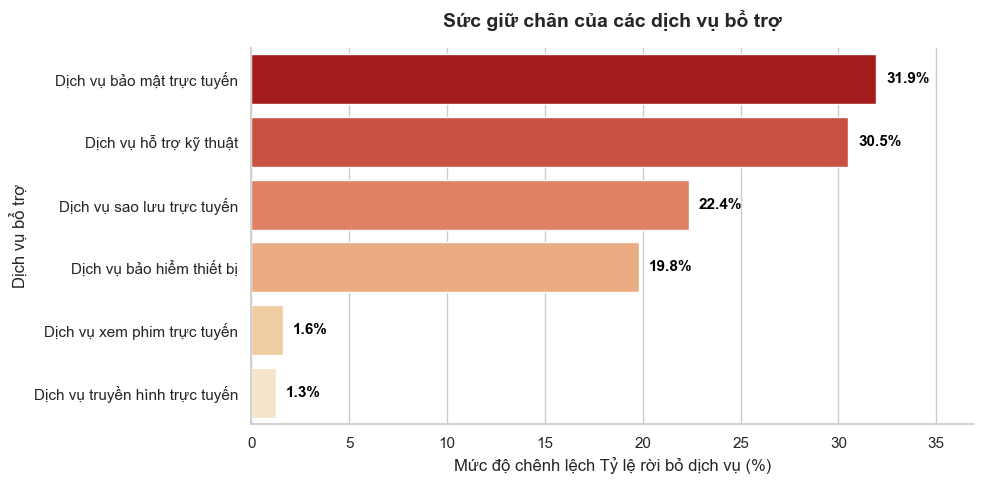

Dịch vụ,Ý nghĩa đặc trưng,Tỷ lệ rời bỏ khi không sử dụng dịch vụ,Tỷ lệ rời bỏ khi sử dụng dịch vụ,Độ chênh lệch
OnlineSecurity,Dịch vụ bảo mật trực tuyến,40.6%,8.7%,31.9%
TechSupport,Dịch vụ hỗ trợ kỹ thuật,40.2%,9.6%,30.5%
OnlineBackup,Dịch vụ sao lưu trực tuyến,39.1%,16.7%,22.4%
DeviceProtection,Dịch vụ bảo hiểm thiết bị,38.1%,18.3%,19.8%
StreamingMovies,Dịch vụ xem phim trực tuyến,29.9%,28.3%,1.6%
StreamingTV,Dịch vụ truyền hình trực tuyến,29.7%,28.5%,1.3%


In [149]:
gap_rows = []

for col in service_cols:
    churn_yes = df_train_copy[df_train_copy[col] == 'Yes']['churn_flag'].mean() * 100
    churn_no = df_train_copy[df_train_copy[col] == 'No']['churn_flag'].mean() * 100
    ten_tieng_viet = config_features.get(col, {}).get('name', col)
    gap_rows.append({
        "Dịch vụ": col,
        "Ý nghĩa đặc trưng": ten_tieng_viet,
        "Tỷ lệ rời bỏ khi không sử dụng dịch vụ": churn_no,
        "Tỷ lệ rời bỏ khi sử dụng dịch vụ": churn_yes,
        "Độ chênh lệch": churn_no - churn_yes
    })

gap_df = pd.DataFrame(gap_rows).sort_values("Độ chênh lệch", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=gap_df, y="Ý nghĩa đặc trưng", x="Độ chênh lệch", palette="OrRd_r", hue="Ý nghĩa đặc trưng", dodge=False, legend=False)

plt.title("Sức giữ chân của các dịch vụ bổ trợ", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mức độ chênh lệch Tỷ lệ rời bỏ dịch vụ (%)", fontsize=12)
plt.ylabel("Dịch vụ bổ trợ", fontsize=12)

plt.xlim(0, gap_df["Độ chênh lệch"].max() + 5)

for p in plt.gca().patches:
    width = p.get_width()
    if width > 0:
        plt.gca().annotate(f'{width:.1f}%',
                           (width + 0.5, p.get_y() + p.get_height() / 2.),
                           ha='left', va='center', fontsize=11, color='black', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

show_cols = [
    "Dịch vụ", 
    "Ý nghĩa đặc trưng", 
    "Tỷ lệ rời bỏ khi không sử dụng dịch vụ", 
    "Tỷ lệ rời bỏ khi sử dụng dịch vụ", 
    "Độ chênh lệch"
]

display(
    gap_df[show_cols].style
    .format({
        'Tỷ lệ rời bỏ khi không sử dụng dịch vụ': '{:.1f}%', 
        'Tỷ lệ rời bỏ khi sử dụng dịch vụ': '{:.1f}%', 
        'Độ chênh lệch': '{:.1f}%'
    })
    .hide(axis="index")
)

**Nhận xét:**  
Phân tích độ chênh lệch **Risk Gap** của 6 dịch vụ bổ trợ đã trực quan hóa sự bất đối xứng về sức giữ chân của hệ sinh thái
- Nhóm dịch vụ Bảo vệ và Hỗ trợ **Security & Support** mang sức giữ chân vững chắc nhất, khi Dịch vụ bảo mật trực tuyến `OnlineSecurity` và Dịch vụ hỗ trợ ký thuật `TechSupport` dẫn đầu tuyệt đối với khả năng kéo giảm tỷ lệ rời bỏ xuống mức một con số, từ khoảng **40%** xuống chỉ còn **8.7%** và **9.6%**. Độ chênh lệch khổng lồ hơn **30%** là minh chứng cho việc khách hàng khi đã giao phó sự an toàn và giải quyết sự cố cho hệ thống thì khả năng rời bỏ của họ trở nên cực kỳ thấp. Các dịch vụ liên quan đến sao lưu và bảo hiểm thiết bị như `OnlineBackup` và `DeviceProtection` cũng duy trì sức giữ chân rất ấn tượng, xấp xỉ **20%**.
- Trái ngược hoàn toàn với kỳ vọng, việc cung cấp nội dung giải trí `StreamingMovies` và `StreamingTV` gần như vô giá trị trong việc giữ chân khách hàng. Tỷ lệ rời bỏ của nhóm dùng và không dùng dịch vụ này gần như tương đương nhau, tạo ra độ chênh lệch siêu nhỏ chỉ **1.3% - 1.6%**. Điều này phản ánh thực tế rằng các dịch vụ Streaming của nhà mạng viễn thông rất dễ bị thay thế bởi các nền tảng bên thứ ba, vì vậy việc tạo ra sự trung thành cốt lõi rất khó xảy ra.

## 5.3 Kỹ thuật Đặc trưng (Feature Engineering)

**Note:** Phần này thực hiện chuyển hóa các **Insights** từ quá trình phân tích đơn biến và song biến thành các đặc trưng phái sinh mới, nhằm cô đọng mật độ thông tin rủi ro, tối ưu hóa không gian biểu diễn dữ liệu, từ đó giúp các mô hình **Machine Learning** dễ dàng tính toán toán học và tìm ra các đường phân tách dự đoán tối ưu.

### 5.3.1 Phân khúc hóa Đặc trưng cốt lõi (Binning & Discretization)

**Note:** Việc rời rạc hóa các biến định lượng mang tính phi tuyến tính cao nhằm mục đích bóc tách các vùng rủi ro hành vi đặc thù được phát hiện ở mục **5.1 Phân tích nhóm biến định lượng**, giảm thiểu tác động của các giá trị ngoại lai và hỗ trợ các mô hình dạng cây **Tree-based models** phân cắt dữ liệu nhanh chóng hơn.
- Nhóm thời gian gắn bó `tenure_group`: Chia tách rõ rệt giữa nhóm khách hàng trong giai đoạn trải nghiệm sớm có nguy cơ bùng nổ rủi ro rời bỏ dịch vụ từ **1** đến **6** tháng và các nhóm khách hàng gắn bó lâu dài khác.
- Nhóm cước phí hàng tháng `charge_segment`: Cô lập phân khúc khách hàng *Phổ thông* quanh mốc **20$** và nhóm khách hàng *Cao cấp nhạy cảm về giá* trên **70$**.

**Note:** Rời rạc hóa Thời gian gắn bó `tenure` với các mốc cắt: 
- *Onboarding* **0-6 tháng**
- *First Year* **6-12 tháng**
- *Second Year* **12-24 tháng**
- *Familiar* **24-48 tháng**
- *Loyal* **trên 48 tháng**

In [125]:

df_train_copy['loyalty_tier'] = pd.cut(
    df_train_copy['tenure'], 
    bins=[0, 6, 12, 24, 48, float('inf')], 
    labels=['Onboarding (0-6 tháng)', 'First Year (7-12 tháng)', 'Second Year (13-24 tháng)', 'Familiar (25-48 tháng)', 'Loyal (trên 48 tháng)'],
    include_lowest=True
)

**Note:** Rời rạc hóa Cước phí hàng tháng `MonthlyCharges` với các mốc cắt
- *Budget* **0-35$**
- *Standard* **35-70$**
- *Premium* **trên 70$**

In [126]:
df_train_copy['charge_segment'] = pd.cut(
    df_train_copy['MonthlyCharges'], 
    bins=[0, 35, 70, float('inf')], 
    labels=['Budget (0-35$)', 'Standard (35-70$)', 'Premium (trên 70$)'],
    include_lowest=True
)

**Note:** Hàm đổi tên đặc trưng, sử dụng cho mục đích hiển thị

In [127]:
new_features = {
    'loyalty_tier': ('Mức độ gắn bó'),
    'charge_segment': ('Phân khúc cước phí')
}

**Note:** 
- Thông thường, các đặc trưng phái sinh sẽ được đưa thẳng vào mô hình tính toán hệ số tương quan. Tuy nhiên, để đảm bảo các đặc trưng `loyalty_tier` và `charge_segment` không bị triệt tiêu thông tin lẫn nhau và thực sự tạo ra các vùng cô lập rủi ro có ý nghĩa hành vi, ta trực quan hóa sự tương tác giữa cặp đặc trưng này với đặc trưng `Churn` bằng một ma trận tương tác Heatmap.  
- Đây là Kỹ thuật Kiểm chứng Tính giao thoa đặc trưng **Interaction Validation**

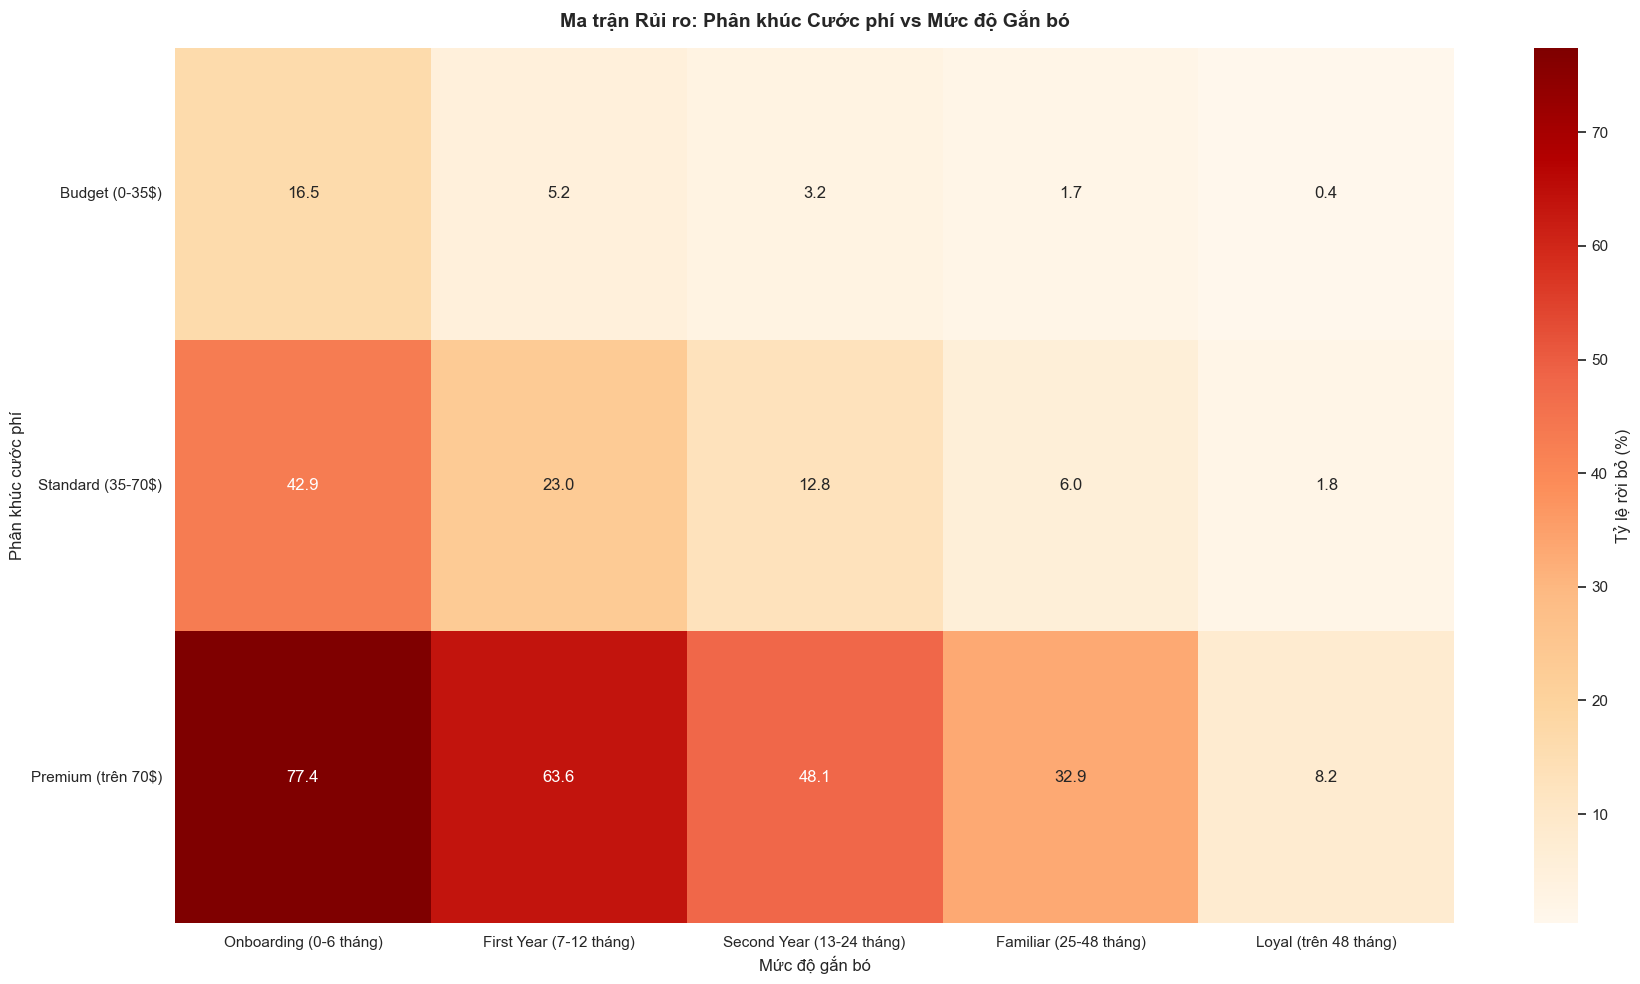

In [128]:
pivot_risk = pd.pivot_table(
    df_train_copy, 
    values='churn_flag', 
    index='charge_segment', 
    columns='loyalty_tier', 
    aggfunc='mean'
) * 100

plt.figure(figsize=(18, 10))
sns.heatmap(pivot_risk, annot=True, fmt=".1f", cmap="OrRd", cbar_kws={'label': 'Tỷ lệ rời bỏ (%)'})
plt.title("Ma trận Rủi ro: Phân khúc Cước phí vs Mức độ Gắn bó", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Phân khúc cước phí", fontsize=12)
plt.xlabel("Mức độ gắn bó", fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Nhận xét:**  
Việc rời rạc hóa các biến định lượng thành `loyalty_tier` và `charge_segment` không chỉ giúp đơn giản hóa không gian biểu diễn của mô hình mà còn bóc tách được hiệu ứng giao thoa rủi ro **Compounding Risk Effect** cực kỳ rõ nét qua ma trận Heatmap:
- Tử huyệt rủi ro ở giai đoạn đầu **Onboarding Crisis**: Điểm bùng nổ khủng hoảng nằm trọn tại giao điểm của nhóm khách hàng mới *Onboarding (0-6 tháng)* và phân khúc *Premium (trên 70$)* với tỷ lệ rời bỏ dịch vụ lên tới mức báo động **77.4%**. Tín hiệu này chỉ ra rằng áp lực chi phí cao ở ngay giai đoạn làm quen dịch vụ chính là ngòi nổ mạnh nhất khiến khách hàng đứt gãy trải nghiệm sớm và rời bỏ hệ thống.
- Lòng trung thành làm giảm độ nhạy cảm về giá: Khi quan sát xu hướng theo chiều ngang của phân khúc *Premium (trên 70$)*, tỷ lệ rời bỏ dịch vụ có xu hướng giảm, tỷ lệ nghịch với thời gian gắn bó từ **77.4%** giai đoạn 0-6 tháng giảm mạnh xuống còn **48.1%** giai đoạn năm hai và chạm mức an toàn **8.2%** khi đạt *Loyal*. Điều này minh chứng cho một Insight đắt giá: Khách hàng không hoàn toàn rời đi chỉ vì giá cao, mà áp lực giá sẽ được xoa dịu đáng kể khi họ đã hòa mạng sâu và nhận được giá trị thực tế từ hệ sinh thái dịch vụ.
- Phân khúc cốt lõi bền vững **Safe Zone**: Ngược lại, nhóm khách hàng thuộc phân khúc *Budget (0-35$)* duy trì một nền tảng rủi ro cực kỳ thấp và ổn định, dao động từ **16.5%** và triệt tiêu dần về **0.4%** ở nhóm *Trung thành*. Đây là nhóm khách hàng có độ trung thành tự nhiên cao nhất do ít chịu áp lực tài chính đột ngột.

**Kết luận:** Biến phái sinh `loyalty_tier` và `charge_segment` đã hoàn thành xuất sắc vai trò phân loại hành vi phi tuyến tính. Sự phân hóa rủi ro rạch ròi giữa các ô trên ma trận Heatmap là minh chứng cho thấy bộ đôi đặc trưng này mang mật độ thông tin **Information Density** rất cao, sẵn sàng làm bệ phóng vững chắc cho các thuật toán phân lớp ở giai đoạn sau.

### 5.3.2. Xây dựng Đặc trưng Tài chính & Biến động Giá (Financial Ratios & Cost Metrics)

**Note:** Thực hiện xây dựng các chỉ số tương tác toán học phản ánh áp lực kinh tế ngắn hạn, nguy cơ sốc giá và đơn giá dịch vụ thực tế mà khách hàng đang gánh chịu. Các biến số liên tục này giúp bóc tách sâu hơn các thuộc tính hành vi nhạy cảm về giá của từng nhóm đối tượng.
- *Tỷ lệ chi phí trên thời gian gắn bó Logarit hóa* `charge_to_tenure_ratio_log`: Định lượng ngưỡng chịu đựng tài chính của khách hàng. Phép biến đổi Logarit được áp dụng nhằm xử lý hiện tượng lệch phải của dữ liệu. Điểm số sau khi chuẩn hóa càng cao càng vạch trần rõ nét rủi ro ngợp chi phí ở những người dùng mới có cước tháng đắt đỏ.
- *Tỷ lệ sốc cước* `bill_shock_ratio`: Đo lường mức độ chênh lệch giữa cước tháng hiện tại với mức chi trả trung bình trong quá khứ. Tỷ lệ này khi lớn hơn **1** báo hiệu rủi ro khách hàng vừa trải qua đợt tăng giá hoặc hết hạn khuyến mãi, dẫn đến tâm lý sốc và dễ rời bỏ.
- *Chi phí trung bình trên mỗi dịch vụ* `average_cost_per_service`: Định lượng độ đắt đỏ thực tế dựa trên tổng số dịch vụ đang sử dụng. Đặc trưng này giúp mô hình phân biệt được khách hàng đang tận hưởng một hệ sinh thái giá rẻ với nhiều dịch vụ, chi phí chia đều thấp và khách hàng đang phải gánh cước phí cao chỉ cho một vài dịch vụ cốt lõi.
- *Tỷ trọng cước tháng trên chi phí chìm* `monthly_to_sunk_ratio`: Định lượng hiệu ứng tâm lý "chi phí chìm" (sunk cost) của người dùng. Đặc trưng này giúp mô hình phân biệt được nhóm khách hàng có rào cản rời đi thấp (hóa đơn tháng hiện tại chiếm tỷ trọng quá lớn trong tổng số tiền họ từng trả) và nhóm khách hàng có tâm lý ngại thay đổi (hóa đơn tháng chỉ là một phần nhỏ so với khoản tiền khổng lồ họ đã đầu tư gắn bó với nhà mạng).

**Note:** Đếm tổng số dịch vụ đang sử dụng của mỗi khách hàng

In [129]:
def count_active_services(row):
    count = 0
    if row['InternetService'] in ['DSL', 'Fiber optic']: count += 1
    if row['PhoneService'] == 'Yes': count += 1
    for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']:
        if row[col] == 'Yes': count += 1
    return count

df_train_copy['total_active_services'] = df_train_copy.apply(count_active_services, axis=1)

**Note:** Xây dựng các đặc trưng tài chính mới
- *Tỷ lệ chi phí trên thời gian gắn bó*  
`charge_to_tenure_ratio_log`$=log($`MonthlyCharges`$/$`tenure`$)$
- *Tỷ lệ sốc cước*  
`bill_shock_ratio`$=$`MonthlyCharges`$/($ `TotalCharges`$/$`tenure`$)$
- *Chi phí trung bình trên mỗi dịch vụ*  
`average_cost_per_service`$=$`MonthlyCharges`$/$ `total_active_services`
- *Tỷ trọng cước tháng trên chi phí chìm*  
`monthly_to_sunk_ratio`$=$`MonthlyCharges`$/$ `TotalCharges`

In [130]:
df_train_copy['charge_to_tenure_ratio_log'] = np.log1p(df_train_copy['MonthlyCharges'] / df_train_copy['tenure'])

historical_monthly_average = df_train_copy['TotalCharges'] / df_train_copy['tenure']
df_train_copy['bill_shock_ratio'] = df_train_copy['MonthlyCharges'] / historical_monthly_average

df_train_copy['average_cost_per_service'] = df_train_copy['MonthlyCharges'] / df_train_copy['total_active_services']

df_train_copy['monthly_to_sunk_ratio'] = df_train_copy['MonthlyCharges'] / df_train_copy['TotalCharges']

financial_ratios = ['charge_to_tenure_ratio_log', 'bill_shock_ratio', 'average_cost_per_service','monthly_to_sunk_ratio']

**Note:** Tiến hành trực quan hóa 4 chỉ số tài chính thông qua biểu đồ phân bố mật độ KDE. Trực quan này đóng vai trò như bộ lọc đầu tiên **Sanity Check** để xác nhận sức mạnh dự đoán của các biến phái sinh trước khi đưa vào huấn luyện mô hình học máy. Đặc trưng nào có độ phân tách tín hiệu **Signal Separation** giữa hai lớp **0** và **1** càng lớn sẽ càng được ưu tiên giữ lại.

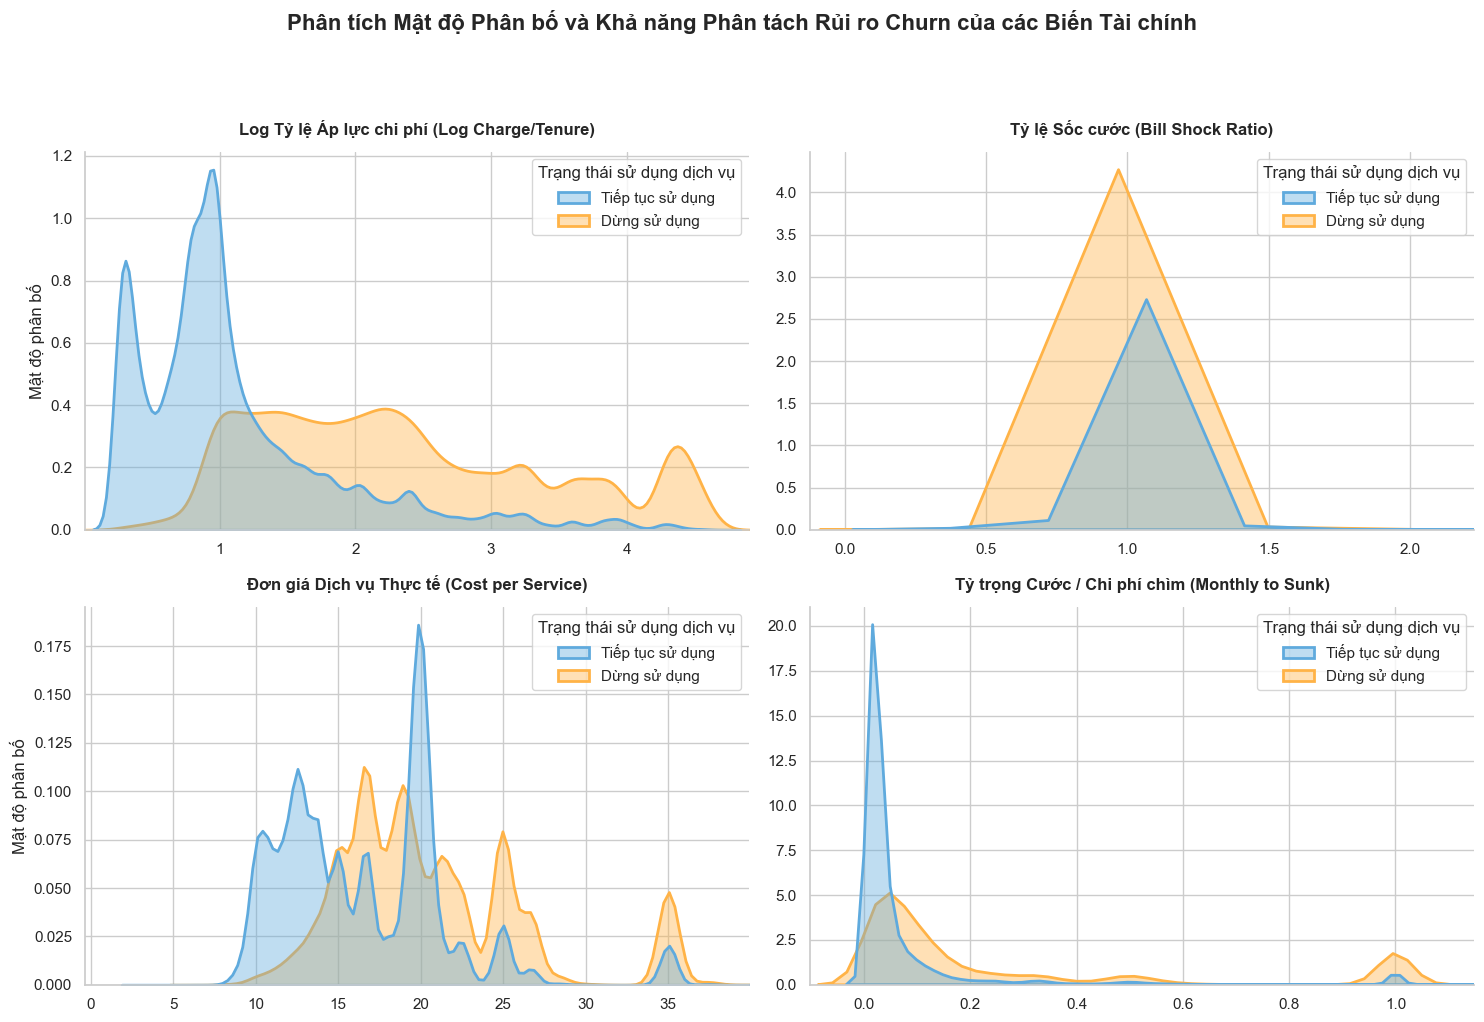

In [131]:
financial_labels = {
    'charge_to_tenure_ratio_log': 'Log Tỷ lệ Áp lực chi phí (Log Charge/Tenure)',
    'bill_shock_ratio': 'Tỷ lệ Sốc cước (Bill Shock Ratio)',
    'average_cost_per_service': 'Đơn giá Dịch vụ Thực tế (Cost per Service)',
    'monthly_to_sunk_ratio': 'Tỷ trọng Cước / Chi phí chìm (Monthly to Sunk)',
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle("Phân tích Mật độ Phân bố và Khả năng Phân tách Rủi ro Churn của các Biến Tài chính", 
             fontsize=16, fontweight='bold', y=1.02)

churn_palette = {0: "#5FAADD", 1: "#FFB347"}
axes_flat = axes.flatten()

for i, col in enumerate(financial_labels.keys()):
    ax = axes_flat[i]

    sns.kdeplot(
        data=df_train_copy, 
        x=col, 
        hue='churn_flag', 
        hue_order=[0, 1],
        fill=True, 
        palette=churn_palette, 
        common_norm=False, 
        linewidth=2,
        alpha=0.4,
        ax=ax
    )
    
    title_vn = financial_labels.get(col, col)
    ax.set_title(title_vn, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("Mật độ phân bố" if i % 2 == 0 else "")
    
    if ax.get_legend():
        ax.get_legend().set_title("Trạng thái sử dụng dịch vụ")
        for text, label in zip(ax.get_legend().get_texts(), ['Tiếp tục sử dụng', 'Dừng sử dụng']):
            text.set_text(label)
    
    min_val = df_train_copy[col].min()
    if col not in ['tenure', 'charge_to_tenure_ratio_log']:
        q99 = df_train_copy[col].quantile(0.999)
        margin = (q99 - min_val) * 0.1 
        ax.set_xlim(min_val - margin, q99 + margin)
    else:    
        max_val = df_train_copy[col].max()
        margin = (max_val - min_val) * 0.05
        ax.set_xlim(min_val - margin, max_val + margin)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Nhận xét:**  
Việc trực quan hóa mật độ phân bố KDE của $4$ biến tài chính phái sinh đã đóng vai trò như một màng lọc **Sanity** Check cực kỳ xuất sắc, không những phân tách tâm lý giữa hai nhóm khách hàng mà còn giúp kiểm chứng độ chính xác của các giả thuyết nghiệp vụ ban đầu:
- Sức mạnh bóc tách tín hiệu **Signal Separation** vượt trội: Ở **Biểu đồ Log Tỷ lệ Áp lực chi phí**, đường phân phối của hai nhóm tách rời nhau một cách hoàn hảo. Nhóm khách hàng tiếp tục sử dụng dịch vụ màu xanh tụ lại thành các đỉnh nhọn ở vùng giá trị thấp, trong khi nhóm rời bỏ dịch vụ màu cam tạo thành một dải phân phối bẹt và kéo dài về bên phải. Điều này khẳng định toán học hóa mức độ ngợp chi phí đã thành công trong việc phát hiện rủi ro.
- Hiệu ứng Chi phí chìm **Sunk Cost Fallacy**: Tại **Biểu đồ Tỷ trọng Cước / Chi phí chìm**, dải màu xanh vút lên thành một đỉnh duy nhất sát mốc **0**, chứng minh nhóm khách hàng lâu năm, vốn có hóa đơn tháng chỉ chiếm phần siêu nhỏ trong tổng chi phí đã đầu tư mang trong mình yếu tố giữ chân cực kỳ vững chắc. Ngược lại, nhóm rời bỏ dịch vụ xuất hiện một đỉnh phụ rõ rệt ở mốc **1.0** — phơi bày "tử huyệt" của nhóm khách hàng mới tinh: khi chưa kịp tích lũy "chi phí chìm", họ sẵn sàng dứt áo ra đi ngay trong tháng đầu tiên nếu không hài lòng.
- Bẫy định giá dịch vụ **Perceived Value Trap**: **Biểu đồ Đơn giá Dịch vụ Thực tế** cho thấy một phân phối đa đỉnh **Multi-modal** rất phức tạp. Tuy nhiên, có thể quan sát rõ ở các vùng đơn giá cao như mốc 25 trở lên, nhóm khách hàng rời bỏ dịch vụ hoàn toàn áp đảo. Khách hàng nhạy cảm không phải vì tổng hóa đơn cao, mà vì họ cảm thấy số tiền bỏ ra không xứng đáng với số lượng tiện ích nhận về, có thể do không nằm trong hệ sinh thái Combo giá rẻ.
- Bác bỏ giả thuyết Sốc cước: Trái ngược với kỳ vọng ban đầu, **Biểu đồ Tỷ lệ Sốc cước** cho thấy hai đường phân phối đè khít lên nhau tạo thành một đỉnh duy nhất tại mốc **1.0**. Điều này phản ánh thực trạng dữ liệu: đa số khách hàng sử dụng gói cước cố định. Do không có sự phân hóa tín hiệu, đặc trưng này trở thành nhiễu **Noise** và cần được loại bỏ.

**Kết luận:** Quá trình **Feature Engineering** nhóm biến định lượng đã mang lại những thành quả khi ba biến phái sinh `charge_to_tenure_ratio_log`, `monthly_to_sunk_ratio` và `average_cost_per_service` sở hữu mật độ thông tin **Information Density** cực cao với khả năng phân loại lớp phi tuyến tính xuất sắc. Đồng thời, quyết định dứt khoát loại bỏ `bill_shock_ratio` ở bước **Feature Pruning** sẽ giúp không gian đặc trưng **Feature Space** trở nên tinh gọn và tối ưu hóa hiệu suất dự đoán ở giai đoạn sau.

### 5.3.3. Phân tích Lỗ hổng Dịch vụ & Thiết lập Cờ Rủi ro (Gaps Analysis & Risk Flags)

**Note:**  
- Dựa trên kết quả phần **5.2 Phân tích nhóm biến định tính (Categorical Features vs Target)**, hành vi rời bỏ của khách hàng bị chi phối mạnh mẽ bởi hai yếu tố mang tính bước ngoặt:
    - Các dịch vụ mang tính chất Bảo vệ & Hỗ trợ `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection` đóng vai trò như một mỏ neo vững chắc giúp giảm rủi ro rời bỏ dịch vụ cực kỳ mạnh mẽ. Ngược lại, nhóm dịch vụ Giải trí `StreamingMovies`, `StreamingTV` lại tỏ ra yếu ớt trong việc giữ chân khách hàng. Việc so sánh một cách tương đồng các biến làm loãng thông tin.
    - Việc phải chủ động trả tiền hàng tháng `Electronic check`, `Mailed check` tạo ra áp lực tâm lý và tỷ lệ rời bỏ cao ngất ngưởng, trong khi sự vô hình của các phương thức thanh toán tự động giúp giữ chân khách hàng tốt hơn.  
- Từ những Insight đắt giá này, mục này sẽ phân rã và kiến tạo các bộ tín hiệu rủi ro chuyên biệt bao gồm điểm số tích lũy `security_score`, `streaming_score` và các cờ nhị phân `no_supportive_service`, `manual_payment` cùng với siêu cờ `composite_risk_profile` để cô lập các vùng hành vi nhạy cảm.

**Note:** Thực hiện xây dựng các thang điểm tích lũy hệ sinh thái
- *Điểm khiên bảo vệ* `Security Shield Score` trên thang **0-4**, gồm **4** dịch vụ cốt lõi đóng vai trò thiết yếu trong việc giữ chân khách hàng.
- *Điểm Giải trí* `Entertainment Score` trên thang **0-2**, gồm các dịch vụ giải trí thuần túy, có sức giữ chân yếu ớt.


In [157]:
protective_cols = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']
df_train_copy['security_score'] = (df_train_copy[protective_cols] == 'Yes').sum(axis=1)

streaming_cols = ['StreamingTV', 'StreamingMovies']
df_train_copy['streaming_score'] = (df_train_copy[streaming_cols] == 'Yes').sum(axis=1)

**Note:** Thiết lập các cờ rủi ro **Risk Flag** nhằm cô lập các vùng rủi ro cao
- *Cờ Không có dịch vụ hỗ trợ* `no_supportive_service` nhằm quan sát nhóm không đăng kí dịch vụ bổ sung, hoặc nhóm chỉ mua gói giải trí mà thiếu đi tấm khiên bảo vệ `security_score` = *0*
- *Cờ Thanh toán chủ động/thủ công* `manual_payment` nhằm cô lập nhóm chịu áp lực tâm lý chi trả hàng tháng *Electronic check*, *Mailed check*
- *Siêu cờ tổ hợp `composite_risk_profile` kích hoạt giá trị **1** nếu đồng thời thỏa mãn cả 3 cờ rủi ro cao nhất

In [169]:
df_train_copy['less_supportive_service'] = (df_train_copy['security_score'] < 2).astype(int)

manual_methods = ['Electronic check', 'Mailed check']
df_train_copy['manual_payment'] = df_train_copy['PaymentMethod'].isin(manual_methods).astype(int)

df_train_copy['composite_risk_profile'] = (
    (df_train_copy['Contract'] == 'Month-to-month') & 
    (df_train_copy['InternetService'] == 'Fiber optic')  
).astype(int)

**Note:** Ta thực hiện trực quan hóa phân phối rủi ro **Risk Spread Analysis**. Các đặc trưng được chia thành hai nhóm cấu trúc chuyên biệt: 
- Hệ thống điểm số tích lũy `security_score`, `streaming_score` để quan sát xu hướng rủi ro biến thiên theo nấc thang dịch vụ
- Hệ thống cờ hiệu rủi ro `less_supportive_service`, `manual_payment`, `composite_risk_profile` để đo lường mức độ bùng nổ tỷ lệ rời bỏ dịch vụ khi xuất hiện điều kiện mang rủi ro cao.

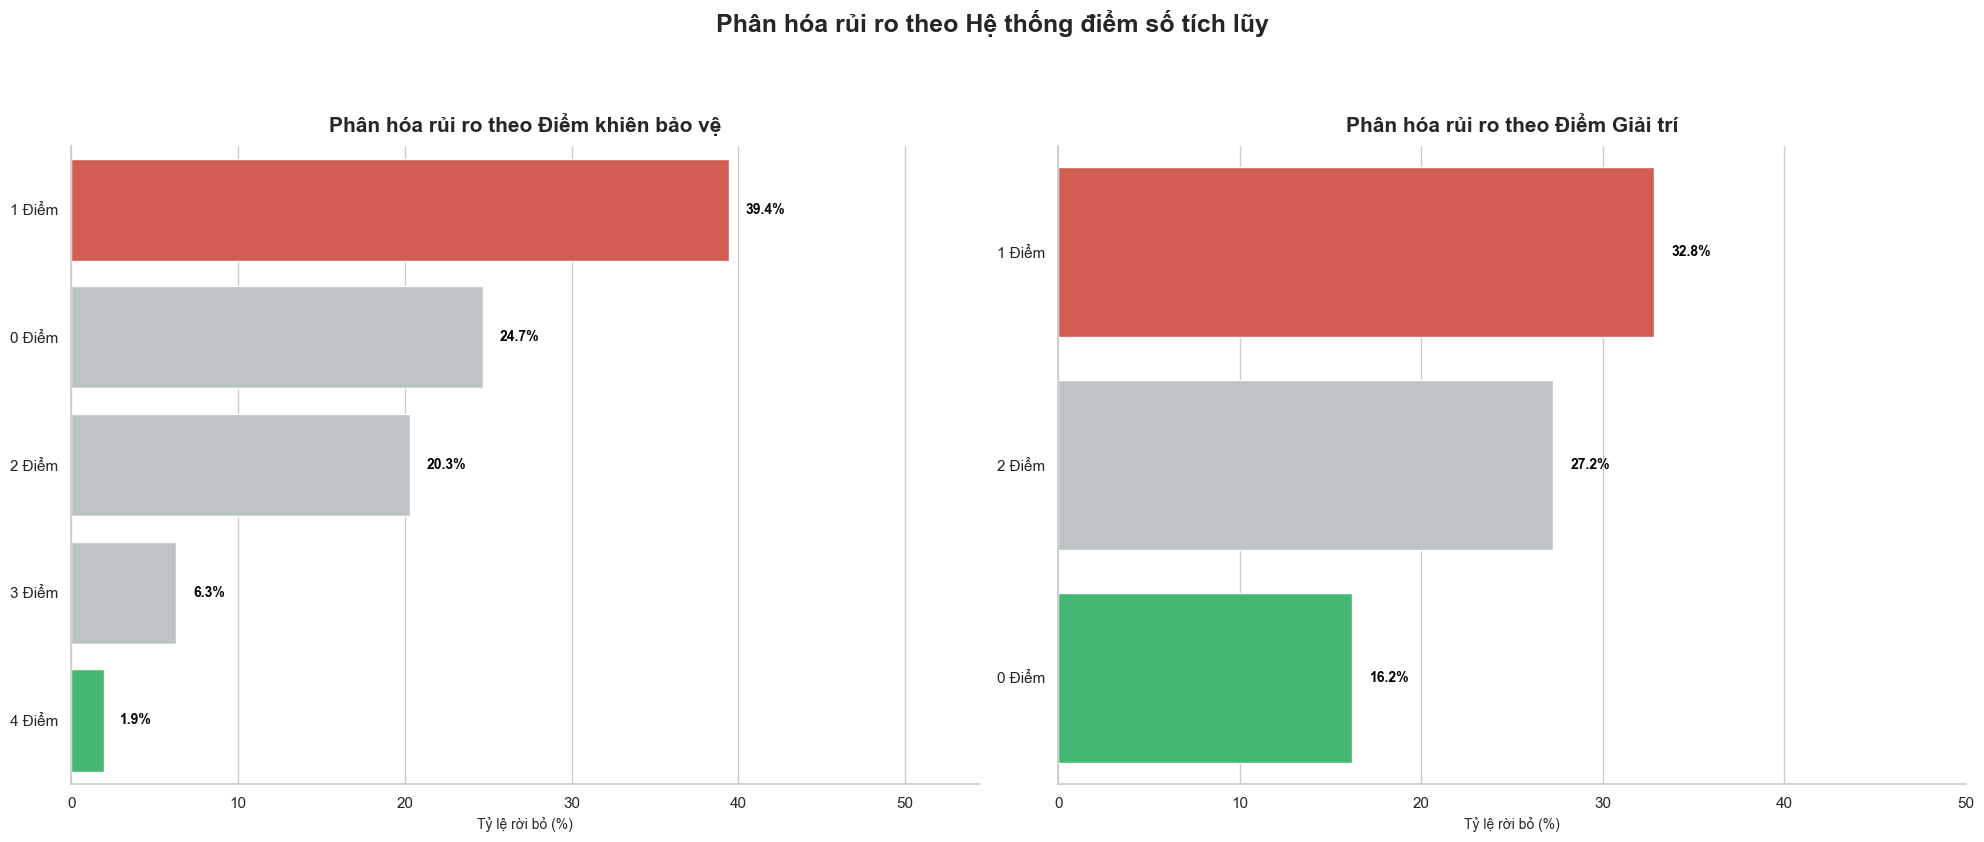

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8)) 
fig.suptitle("Phân hóa rủi ro theo Hệ thống điểm số tích lũy", fontsize=18, fontweight='bold', y=1.05)

plot_sec = df_train_copy.groupby("security_score")["churn_flag"].mean().mul(100).sort_values(ascending=False).reset_index(name="churn_rate")
plot_sec["security_score_lbl"] = plot_sec["security_score"].astype(str) + " Điểm"

palette_sec = ["#E74C3C" if i == 0 else ("#2ECC71" if i == len(plot_sec) - 1 else "#BDC3C7") for i in range(len(plot_sec))]

sns.barplot(data=plot_sec, y="security_score_lbl", x="churn_rate", ax=axes[0], palette=palette_sec, hue="security_score_lbl", legend=False)
axes[0].set_title("Phân hóa rủi ro theo Điểm khiên bảo vệ", fontsize=15, fontweight='bold', pad=10)
axes[0].set_xlabel("Tỷ lệ rời bỏ (%)", fontsize=10)
axes[0].set_ylabel("")
axes[0].set_xlim(0, max(50, plot_sec["churn_rate"].max() + 15))

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.1f}%', (p.get_width() + 1, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10, color='black', fontweight='bold')
sns.despine(ax=axes[0])

plot_str = df_train_copy.groupby("streaming_score")["churn_flag"].mean().mul(100).sort_values(ascending=False).reset_index(name="churn_rate")
plot_str["streaming_score_lbl"] = plot_str["streaming_score"].astype(str) + " Điểm"

palette_str = ["#E74C3C" if i == 0 else ("#2ECC71" if i == len(plot_str) - 1 else "#BDC3C7") for i in range(len(plot_str))]

sns.barplot(data=plot_str, y="streaming_score_lbl", x="churn_rate", ax=axes[1], palette=palette_str, hue="streaming_score_lbl", legend=False)
axes[1].set_title("Phân hóa rủi ro theo Điểm Giải trí", fontsize=15, fontweight='bold', pad=10)
axes[1].set_xlabel("Tỷ lệ rời bỏ (%)", fontsize=10)
axes[1].set_ylabel("")
axes[1].set_xlim(0, max(50, plot_str["churn_rate"].max() + 15))

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_width():.1f}%', (p.get_width() + 1, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10, color='black', fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ so sánh trực quan hai thang điểm hệ sinh thái thể hiện rõ nét sự phân hóa rủi ro phi tuyến tính cũng như sự chính xác trong quyết định tách biệt *Khiên bảo vệ* và *Giải trí* 
- Điểm Khiên bảo vệ `Security Score`: Nhóm **0** Điểm, bản chất là tệp khách hàng lõi *Không sử dụng Internet* có tỷ lệ rời bỏ dịch vụ đạt **24.7%**, thấp hơn nhóm **1** Điểm với **39.4%**. Tuy nhiên, ngay khi khách hàng bắt đầu sử dụng Internet và tham gia vào hệ sinh thái bảo mật, tỷ lệ rời bỏ dịch vụ giảm mạnh, từ **39.4%** xuống chỉ còn **1.9%**, thể hiện sức giữ chân mạnh mẽ của nhóm dịch vụ bổ sung này.

- Điểm Giải trí `Streaming Score`: Trái ngược hoàn toàn với nhóm Khiên bảo vệ, việc tích lũy các dịch vụ Giải trí không hề mang lại sự giữ chân như kỳ vọng. Nhóm khách hàng sở hữu **1** hoặc **2** dịch vụ Streaming lại ghi nhận tỷ lệ rời bỏ báo động, lần lượt là **32.8%** và **27.2%**. Trong khi đó, nhóm **0** Điểm, vốn không đăng ký Streaming lại có mức rủi ro thấp nhất **16.2%**. Điều này một lần nữa khẳng định các dịch vụ xem phim/truyền hình không tạo ra được sự gắn bó cốt lõi của khách hàng đối với dịch vụ.

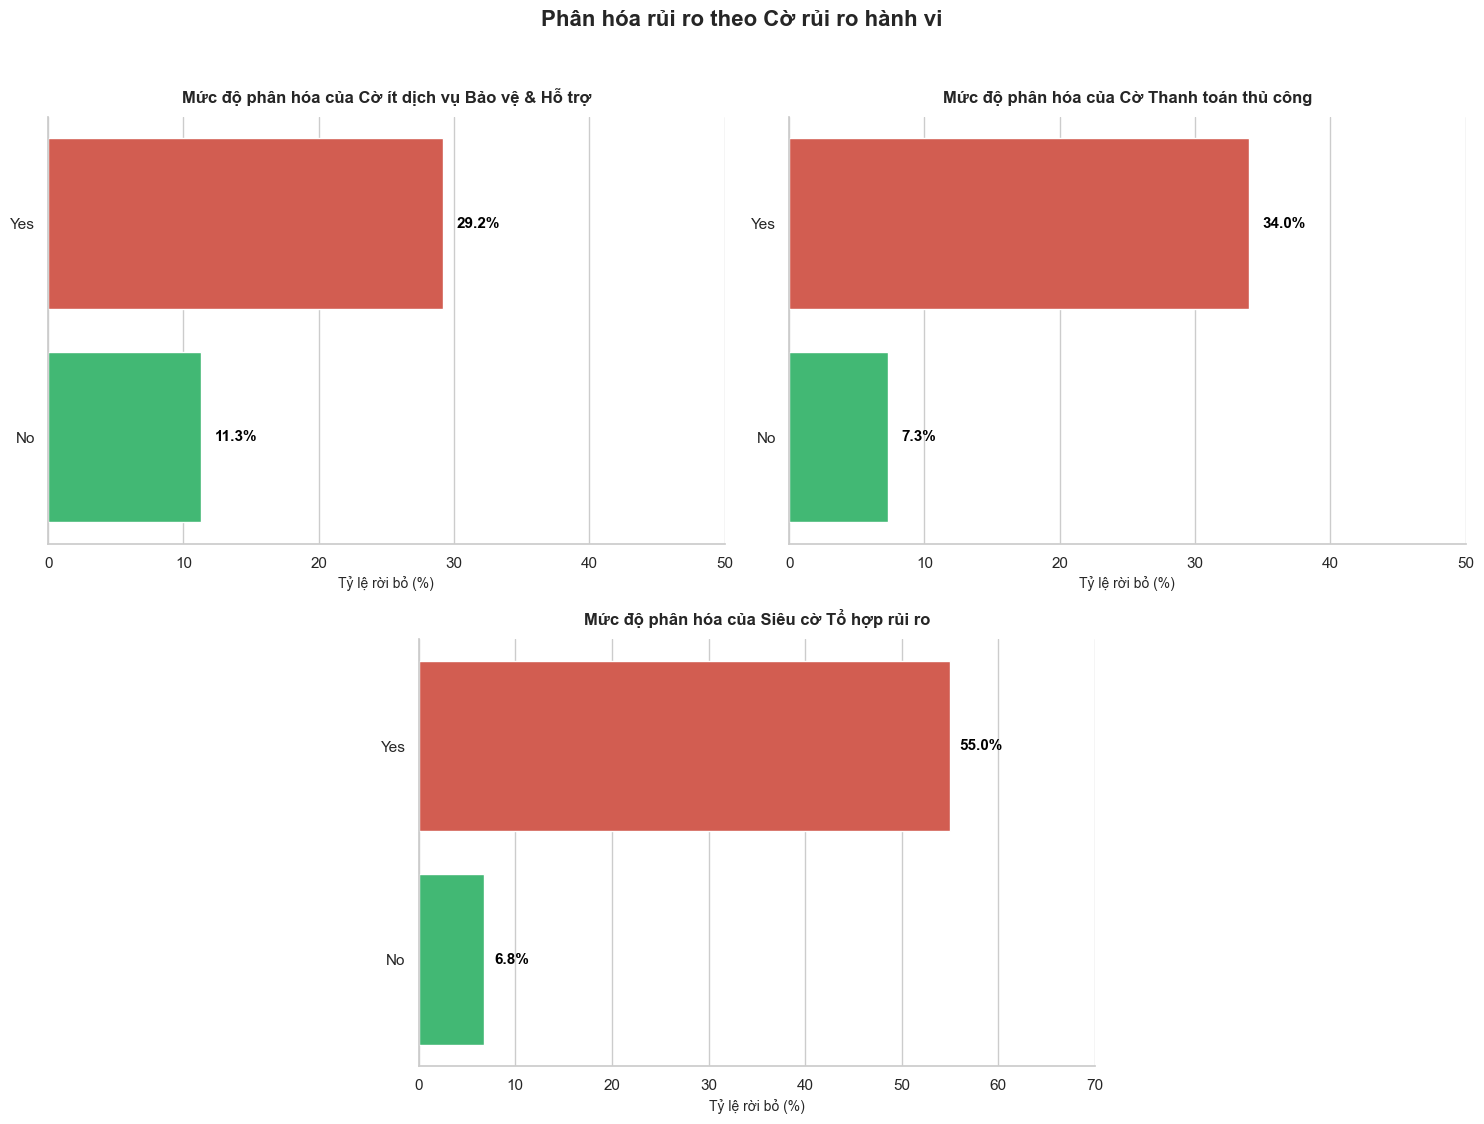

In [175]:
flag_features = ["less_supportive_service", "manual_payment", "composite_risk_profile"]
flag = {0: "No", 1: "Yes"}
flag_titles = {
    "less_supportive_service": "Cờ ít dịch vụ Bảo vệ & Hỗ trợ",
    "manual_payment": "Cờ Thanh toán thủ công",
    "composite_risk_profile": "Siêu cờ Tổ hợp rủi ro"
}

fig = plt.figure(figsize=(15, 11)) 
fig.suptitle("Phân hóa rủi ro theo Cờ rủi ro hành vi", fontsize=16, fontweight='bold', y=1.02)

ax1 = plt.subplot2grid((2, 4), (0, 0), colspan=2)
ax2 = plt.subplot2grid((2, 4), (0, 2), colspan=2)
ax3 = plt.subplot2grid((2, 4), (1, 1), colspan=2)

axes_list = [ax1, ax2, ax3]

for ax, feature in zip(axes_list, flag_features):
    plot_data = df_train_copy.groupby(feature)["churn_flag"].mean().mul(100).sort_values(ascending=False).reset_index(name="churn_rate")
    
    plot_data["display_label"] = plot_data[feature].map(flag)
    
    risk_palette = ["#E74C3C" if i == 0 else ("#2ECC71" if i == len(plot_data) - 1 else "#BDC3C7") for i in range(len(plot_data))]

    sns.barplot(
        data=plot_data, 
        y="display_label", 
        x="churn_rate", 
        ax=ax,
        palette=risk_palette,
        hue="display_label",
        legend=False
    )
    
    ax.set_title(f"Mức độ phân hóa của {flag_titles[feature]}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Tỷ lệ rời bỏ (%)", fontsize=10)
    ax.set_ylabel("")
    ax.set_xlim(0, max(50, plot_data["churn_rate"].max() + 15)) 
    
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}%', 
                    (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', fontsize=11, color='black', fontweight='bold')

    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

**Nhận xét:** Việc thiết lập các *Cờ rủi ro hành vi* đã thành công phát hiện các vùng rủi ro cao khiến khách hàng rời bỏ dịch vụ, từ các lỗ hổng đơn lẻ đến hiệu ứng cộng hưởng rủi ro
- *Cờ ít dịch vụ hỗ trợ* **< 2** dịch vụ nhắm đến nhóm khách hàng thiếu các dịch vụ bảo vệ và hỗ trợ từ hệ sinh thái này, mang tỷ lệ rời đi lên đến **29.2%**, cao gấp gần **3** lần so với nhóm được trang bị đầy đủ các dịch vụ tương tự **11.3%**.
- *Cờ Thanh toán thủ công*: Sự bất tiện khi đóng cước bằng các phương thức cũ *Electronic check*/*Mailed check* đẩy tỷ lệ rời bỏ dịch vụ lên **34.0%**, trong khi hệ thống thanh toán tự động giữ ở mức rất an toàn **7.3%**.
- *Siêu cờ Tổ hợp* *Fiber Optic + Month-to-month* là thành quả ấn tượng nhất của bước **Feature Engineering**. Bằng cách kết hợp rủi ro từ việc sử dụng hạ tầng đắt đỏ *Cáp quang* với thời gian hợp đồng ngắn theo từng tháng, một phân khúc rủi ro tột độ đã được phát hiện, với tỷ lệ rời bỏ dịch vụ chạm đỉnh **55.0%** — nghĩa là cứ **20** người thuộc nhóm này thì sẽ có **11** người chắc chắn rời đi.

**Kết luận:** Bước Kỹ thuật Đặc trưng này đã thành công chuyển hóa các phát hiện định tính từ phần Khám phá Dữ liệu **EDA** thành những tín hiệu định lượng mang mật độ thông tin **Information Density** cực cao:
- **Hệ thống Điểm số tích lũy** đã khắc họa bằng toán học sự phân hóa của hệ sinh thái, giúp mô hình nhận diện rõ sự khác biệt giữa nhóm dịch vụ mang tính Khiên bảo vệ vốn có sức giữ chân cực cao và nhóm Tiện ích bề mặt mang tính giải trí, dễ dàng bị thay thế.
- Việc thiết lập các **Cờ rủi ro hành vi** không chỉ cô lập được các rủi ro đơn lẻ như thanh toán thủ công, thiếu dịch vụ hỗ trợ mà còn phơi bày vùng rủi ro của toàn hệ thống thông qua **Siêu cờ Tổ hợp** với tỷ lệ rời bỏ chạm đỉnh **55.0%**, mang tiềm năng trở thành điểm ưu việt trong thuật toán phân lớp.

### 5.4 Phân tích tương quan (Correlation Analysis)

**Note:** Sau khi hoàn tất quá trình Khai phá và Biến đổi đặc trưng *Feature Engineering*, bước Phân tích Tương quan *Correlation Analysis* đóng vai trò như lưới lọc *filter* cuối cùng và nghiêm ngặt nhất, với $4$ nhiệm vụ cốt lõi:
- Tối ưu hóa Phương pháp Thống kê: Áp dụng Cramér's V để khám phá biến định tính nguyên bản, Pearson cho các biến định lượng/nhị phân, và Spearman để đo lường xu hướng thứ bậc. Việc này tránh sai số toán học khi đánh giá chéo các kiểu dữ liệu khác nhau.
- Kiểm định Đặc trưng *Feature Validation*: So sánh chất lượng *Risk Flags* và Đặc trưng tổ hợp với các Đặc trưng gốc về sự tiệm cận nguyên nhân cốt lõi dẫn đến sự rời bỏ khách hàng, thông qua hệ số tương quan đã được tính trước đó
- Sàng lọc Đa cộng tuyến *Multicollinearity Check*: Phát hiện và cô lập các biến độc lập có độ trùng lặp thông tin quá lớn, giúp giảm nhiễu và ngăn chặn sự sai lệch trọng số trong mô hình.
- Hoàn thành danh sách Đặc trưng (Final Feature Selection): Rút trích ra bộ tính năng *features* ưu tú và tinh gọn nhất, giữ lại những tín hiệu dự đoán mạnh mẽ nhất nhằm chuẩn bị cho các khâu kiểm thử *Test Drift* phía sau

**Khám phá Tương quan Biến định tính nguyên bản so với Churn(Cramér's V)**

*Note:* *Hệ số Pearson* truyền thống không thể áp dụng cho các biến phân loại nguyên bản mang giá trị chuỗi văn bản như *Contract*, *InternetService*, *PaymentMethod*. Thay cho phương pháp mặc định, chúng ta sử dụng *Cramér's V* — một thước đo thống kê dựa trên *Kiểm định Chi-bình phương ($\chi^2$)* nhằm định lượng sức mạnh liên kết giữa hai biến danh nghĩa (Nominal variables).

In [135]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    min_dim = min((kcorr-1), (rcorr-1))
    if min_dim == 0:
        return 0
    return np.sqrt(phi2corr / min_dim)

**Note:** Công thức cơ sở:  
$V = \sqrt{\frac{\chi^2 / n}{\min(k-1, r-1)}}$

In [136]:
cramer_rows = []
for col in categorical_features:
    if col in df_train_copy.columns:
        score = cramers_v(df_train_copy[col], df_train_copy['churn_flag'])
        cramer_rows.append({
            "Đặc trưng": col,
            "Hệ số Cramér's V": score
        })

df_cramer = pd.DataFrame(cramer_rows).sort_values("Hệ số Cramér's V", ascending=False)

**Note:** Tạo *DataFrame* chứa đặc trưng định tính nguyên bản và hệ số tương quan tương ứng

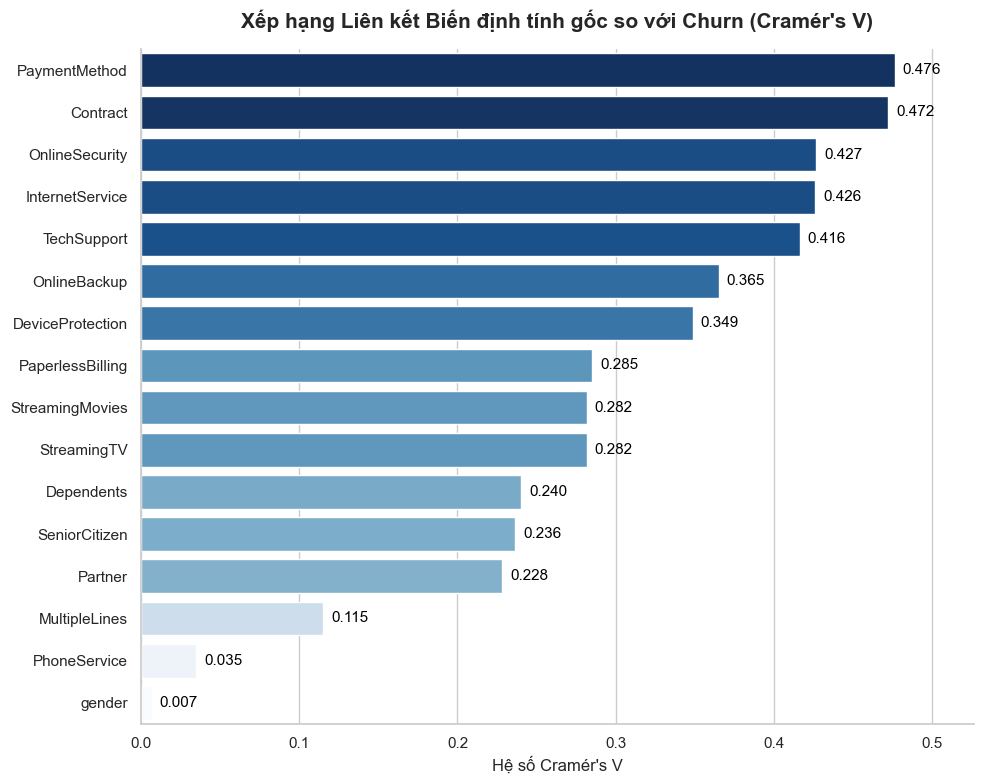

In [137]:


plt.figure(figsize=(10, 8))
sns.barplot(data=df_cramer, y="Đặc trưng", x="Hệ số Cramér's V", 
            palette="Blues", hue="Hệ số Cramér's V", dodge=False, legend=False)

plt.title("Xếp hạng Liên kết Biến định tính gốc so với Churn (Cramér's V)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Hệ số Cramér's V", fontsize=12)
plt.ylabel("")

plt.xlim(0, df_cramer["Hệ số Cramér's V"].max() + 0.05)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_width():.3f}', 
                       (p.get_width() + 0.005, p.get_y() + p.get_height() / 2.), 
                       ha='left', va='center', fontsize=11, color='black')

sns.despine()
plt.tight_layout()
plt.show()

**Nhận xét:**
- Nhóm *Thông tin Giao dịch/Hợp đồng* **PaymentMethod**, **Contract** và *Dịch vụ Internet/Bảo mật* **OnlineSecurity**, **InternetService**, **TechSupport** đứng đầu bảng xếp hạng với hệ số tương quan rất cao $V > 0.4$. Điều này chứng tỏ quyết định xây dựng các Cờ rủi ro *Risk Flags* như **flag_month_to_month** hay **flag_electronic_check** là hoàn toàn chuẩn xác
- Biến *Nhân khẩu học gender* $0.007$ và các dịch vụ thoại cơ bản như *PhoneService* $0.035$, *MultipleLines* $0.115$ có hệ số tương quan với Churn gần như bằng 0. Tín hiệu này cho phép chúng ta loại bỏ các biến này ở khâu hoàn thành danh sách cuối cùng để giúp mô hình học nhanh và tránh nhiễu.

**Khám phá Tương quan Biến Định lượng nguyên bản so với Churn (Pearson)**

**Note:** Nếu *Cramér's V* là thước đo chuyên dụng cho biến định tính, thì đối với nhóm biến định lượng liên tục nguyên bản **tenure**, **MonthlyCharges**, **TotalCharges**, ta sử dụng *Hệ số tương quan Pearson $r$* làm tiêu chuẩn đánh giá. Việc lập ma trận tương quan ở bước này phục vụ $2$ mục tiêu quan trọng:
- Kiểm soát Đa cộng tuyến *Multicollinearity*: Rà soát độ chồng chéo thông tin giữa các biến độc lập
- Đo lường *Lực đẩy/Lực giữ*: Thực hiện xác định tác động thuận hay nghịch của các biến định lượng nguyên bản đến quyết định rời bỏ dịch vụ, từ đó đưa ra quyết định giữ hay loại bỏ biến gốc trước khi đưa vào mô hình.

**Note:** Công thức cơ sở:  

$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$.  

Hệ số Pearson dao động từ $-1$ tương quan nghịch hoàn hảo đến 1 tương quan thuận hoàn hảo. Đối với các biến mang giá trị số học liên tục *continuous variables*, *hệ số Pearson* là công cụ đo lường quan hệ tuyến tính nhạy bén nhất. Nó giúp lượng hóa chính xác tỷ lệ thuận/nghịch giữa chi phí, thời gian với tỷ lệ rời bỏ, đồng thời là "máy quét" tiêu chuẩn để phát hiện *Đa cộng tuyến* – yếu tố gây nhiễu trọng số lớn nhất của các mô hình Machine Learning sau này.

In [138]:
quant_features = numerical_features + ['churn_flag']

corr_quant = (
    df_train_copy[quant_features]
    .rename(columns={'churn_flag': 'ChurnFlag', 'tenure': 'Tenure'})
    .corr()
)

**Note:** Tạo *DataFrame* chứa đặc trưng định lượng nguyên bản và hệ số tương quan tương ứng

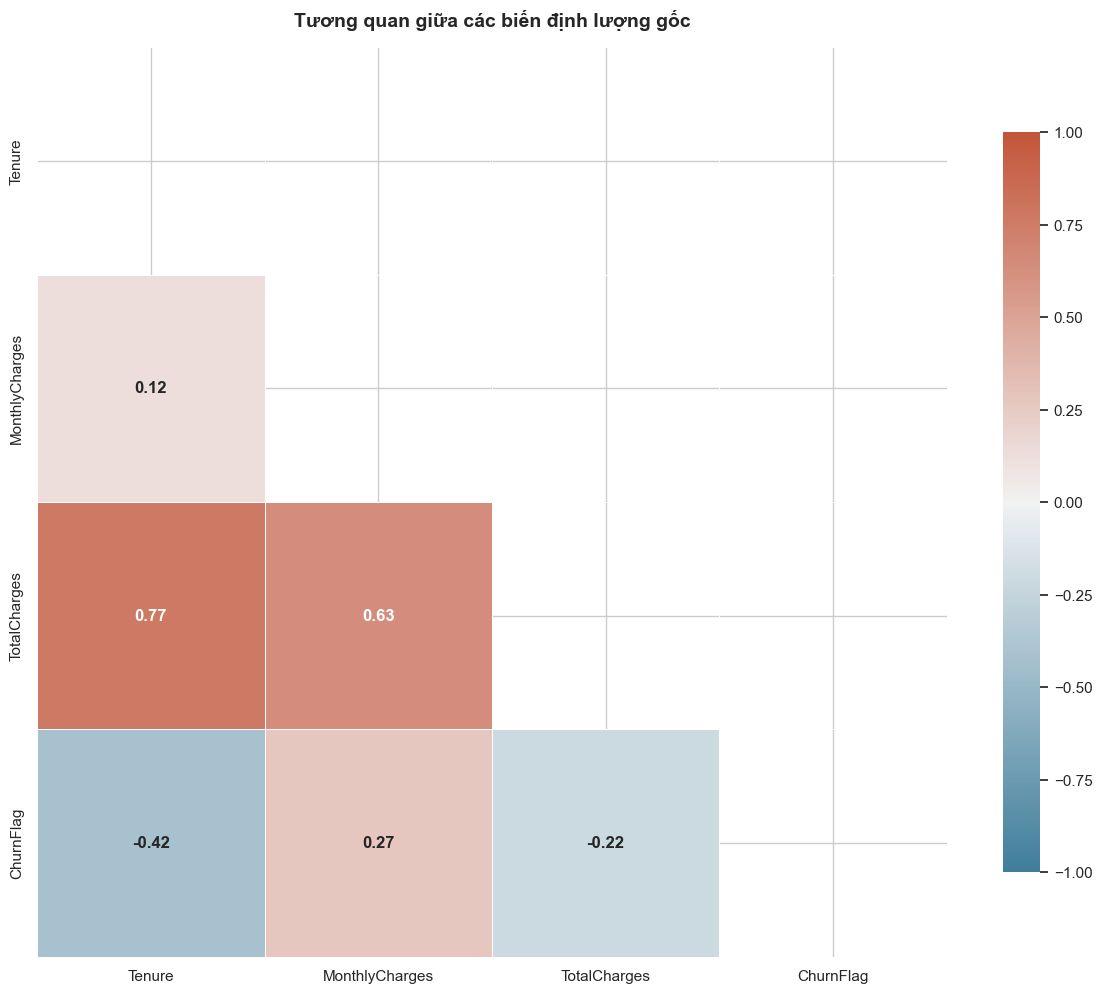

In [139]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_quant, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_quant, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
    annot=True, fmt='.2f', square=True, linewidths=.5, 
    cbar_kws={"shrink": .8}, annot_kws={"size": 12, "fontweight": "bold"} 
)

plt.title("Tương quan giữa các biến định lượng gốc", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Nhận xét:**
- **TotalCharges** có độ tương quan rất cao với tenure $0.77$ và MonthlyCharges $0.63$. Về bản chất, *Tổng chi phí* được tính dựa trên *Thời gian sử dụng* và *Phí hàng tháng*. Để tránh làm nhiễu mô hình và tối ưu hóa số chiều dữ liệu, ta loại bỏ **TotalCharges** ra khỏi danh sách đặc trưng cuối cùng.
- **tenure** $-0.42$ là nhân tố giữ chân khách hàng mạnh mẽ nhất trong nhóm định lượng, trong khi **MonthlyCharges** $0.27$ là yếu tố khiến khách hàng rời bỏ dịch vụ. Cả hai biến này đều chứa tín hiệu tốt và sẽ được giữ lại.

**Khám phá Tương quan Xu hướng Thứ bậc so với Churn (Spearman)**

**Note:** Đối với các đặc trưng mang tính thứ bậc *Ordinal Variables* như các nhóm phân khúc **loyalty_tier**, **charge_segment**, **spending_shift** hoặc biến đếm số lượng dịch vụ **total_services**, *hệ số Pearson* sẽ không đạt hiệu quả tối ưu do bản chất các khoảng cách không thực sự tuyến tính hoàn hảo. Thay vào đó, chúng ta sử dụng Hệ số tương quan hạng Spearman ($\rho$).

**Note:** Công thức cơ sở

$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$

Hệ số Spearman đo lường mối quan hệ đơn điệu *monotonic*: Khi giá trị của biến này tăng lên thứ hạng cao hơn, liệu rủi ro rời bỏ dịch vụ có tăng hoặc giảm theo một chiều hướng nhất định hay không? Kết quả từ bước này giúp đánh giá trực tiếp hiệu quả của việc phân nhóm dữ liệu *Binning* ở bước Khai phá đặc trưng *Feature Engineering*.

In [140]:
ordinal_mappings = {
    'loyalty_tier': {'Onboarding': 1, 'First Year': 2, 'Second Year': 3, 'Familiar': 4, 'Loyal': 5},
    'charge_segment': {'Budget': 1, 'Standard': 2, 'Premium': 3},
    'spending_shift': {'Discount/Downgraded': 1, 'Stable/No Changes': 2, 'Upgraded/Surcharge': 3}
}

**Note:** Thực hiện xếp hạng các biến tương ứng để tính *Hệ số Spearman*

In [141]:
spearman_rows = []

for col in new_features:
    if col in ordinal_mappings:
        numeric_series = df_train_copy[col].map(ordinal_mappings[col])
    else:
        numeric_series = df_train_copy[col]
    score = numeric_series.astype(float).corr(df_train_copy['churn_flag'], method='spearman')
    spearman_rows.append({
        "Đặc trưng": display_names.get(col, col),
        "Hệ số Spearman": score
    })

df_spearman = pd.DataFrame(spearman_rows).sort_values("Hệ số Spearman", ascending=False)

NameError: name 'display_names' is not defined

**Note:** Tạo *DataFrame* chứa đặc trưng xu hướng thứ bậc và hệ số tương quan tương ứng

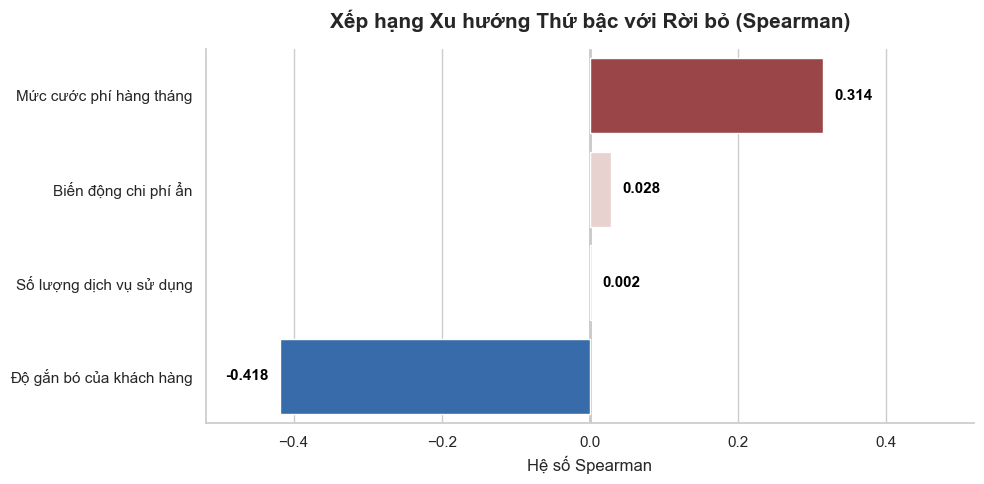

In [ ]:
plt.figure(figsize=(10, 5)) 

sns.barplot(data=df_spearman, y="Đặc trưng", x="Hệ số Spearman", 
            palette="vlag", hue="Hệ số Spearman", dodge=False, legend=False)

plt.title("Xếp hạng Xu hướng Thứ bậc với Rời bỏ (Spearman)", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Hệ số Spearman", fontsize=12)
plt.ylabel("")


for p in plt.gca().patches:
    val = p.get_width()
    offset = 0.015 if val > 0 else -0.015
    ha_align = 'left' if val > 0 else 'right'
    
    plt.gca().annotate(f'{val:.3f}', 
                       (val + offset, p.get_y() + p.get_height() / 2.), 
                       ha=ha_align, va='center', fontsize=11, color='black', fontweight='bold')

max_abs = df_spearman["Hệ số Spearman"].abs().max() + 0.1
plt.xlim(-max_abs, max_abs)

sns.despine()
plt.axvline(x=0, color='#000000', linewidth=1, linestyle='-', zorder=0)
plt.tight_layout()
plt.show()

**Khám phá Tương quan Cờ rủi ro so với Churn (Pearson)**

**Nhận xét:** Biểu đồ trực quan ma trận tương quan ở bước này phục vụ $2$ mục tiêu cốt lõi:
- Kiểm chứng các biến mới *Feature Validation*: Xác nhận các *Risk Flags* thực sự tiệm cận nguyên nhân cốt lõi dẫn đến sự rời bỏ của khách hàng, thể hiện qua hệ số tương quan dương rõ rệt với **churn_flag**.
- Kiểm soát Đa cộng tuyến *Multicollinearity Check*: Giám sát chặt chẽ tương quan nội bộ giữa các biến, đặc biệt là giữa Siêu cờ tổ hợp *flag_high_risk_profile* và các cờ thành phần tạo nên nó. Mục tiêu là đảm bảo việc gộp biến sinh ra giá trị gia tăng chứ không vi phạm quy tắc trùng lặp dữ liệu, với ngưỡng an toàn hệ số $< 0.8$.

**Note:** Ta tiếp tục sử dụng *Phương pháp Pearson* để đánh giá Cờ rủi ro *Risk Flags*. Về mặt toán học, khi áp dụng hệ số $Pearson$ cho các biến chỉ mang giá trị nhị phân, công thức sẽ tương đương với Hệ số Phi ($\phi$) — thước đo chuẩn mực và tối ưu nhất để đánh giá sự tương quan của các biến nhị phân.

In [ ]:
risk_features = [
    'flag_month_to_month', 'flag_electronic_check', 'flag_fiber_optic', 
    'flag_no_tech_support', 'flag_no_online_security', 'flag_high_risk_profile',
    'churn_flag'
]

rename_map = {
    'flag_month_to_month': 'Flag Month-to-Month',
    'flag_electronic_check': 'Flag Electronic Check',
    'flag_fiber_optic': 'Flag Fiber Optic',
    'flag_no_tech_support': 'Flag No Tech Support',
    'flag_no_online_security': 'Flag No Online Security',
    'flag_high_risk_profile': 'Flag High Risk Profile',
    'churn_flag': 'ChurnFlag'
}

**Note:** Liệt kê các *Risk Flags* và đổi tên tương ứng để hiển thị

In [ ]:
corr_risk = (
    df_train_copy[risk_features]
    .rename(columns=rename_map)
    .corr()
)

**Note:** Tạo *DataFrame* chứa *Risk Flags* và hệ số tương quan tương ứng

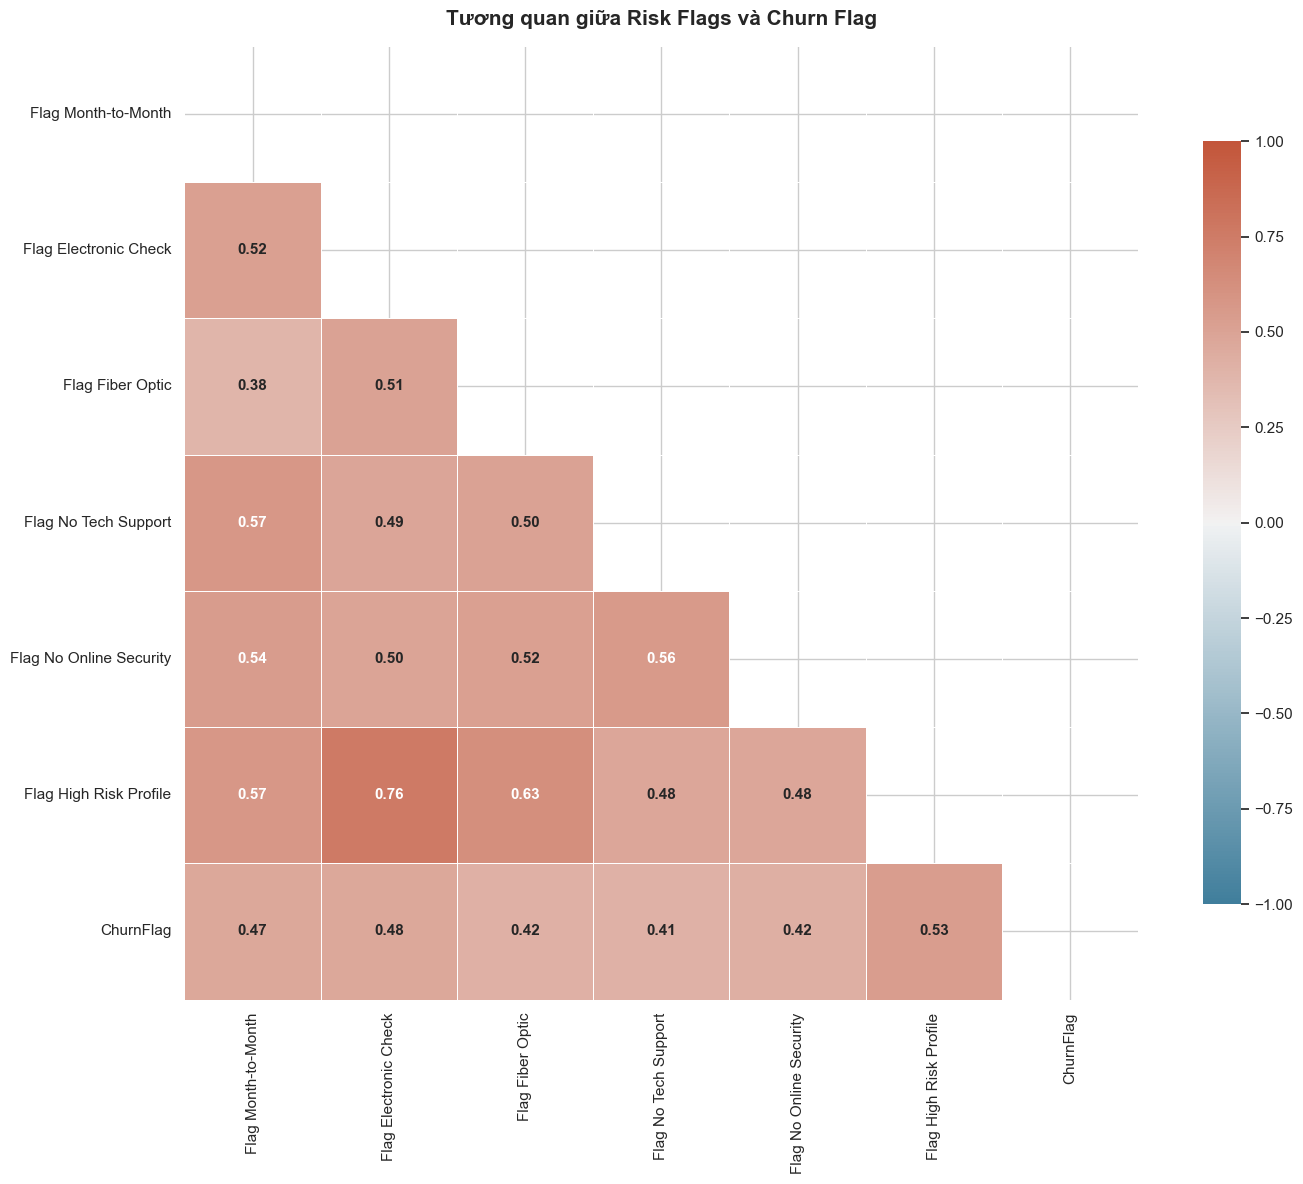

In [ ]:
plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(corr_risk, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_risk, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
    annot=True, fmt='.2f', square=True, linewidths=.5, 
    cbar_kws={"shrink": .8}, annot_kws={"size": 11, "fontweight": "bold"} 
)

plt.title("Tương quan giữa Risk Flags và Churn Flag", fontsize=15, fontweight='bold', pad=15)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Các *Risk Flags* không bị ảnh hưởng quá mức bởi hiện tượng Đa cộng tính *Multicollinearity*. Mức tương quan nội bộ cao nhất nằm ở cặp *flag_high_risk_profile* và *flag_electronic_check*, đạt mức 0.76. Tuy hệ số tương quan khá cao do cấu tạo của siêu cờ, con số này vẫn nằm dưới ngưỡng an toàn $< 0.8$. Vì vậy, ta có thể tạm thời giữ lại tất cả các *risk flags* ở giai đoạn này để thực hiện so sánh tính ưu việt so với các biến gốc thông qua hệ số tương quan với **Churn** .Cặp dịch vụ bổ trợ *flag_no_tech_support* và *flag_no_online_security* có độ tương quan vừa phải $0.56$, cho thấy khách hàng thường có xu hướng cùng lúc bỏ qua cả hai lớp bảo vệ này.
- Toàn bộ các biến mới đều có hệ số tương quan dương và ở mức rất tốt $> 0.4$ với biến mục tiêu. Điều này chứng minh các cờ này thực sự là những tác nhân cốt lõi khiến khách hàng rời đi.
- *flag_high_risk_profile* chứng minh được tính ưu việt của Feature Engineering khi dẫn đầu về sự tương quan với biến mục tiêu, đạt $0.53$. Siêu cờ đã tổng hợp thành công các rủi ro rời rạc thành một tín hiệu cảnh báo cực mạnh.

**Tổng hợp và Hoàn thành danh sách Đặc trưng Final Feature Selection**

**Note:** Sau quá trình cô lập và đánh giá dữ liệu thông qua $4$ bộ lọc thống kê chuyên biệt, bước cuối cùng tập trung vào việc chọn lọc những đặc trưng có độ tương quan mạnh nhất với biến mục tiêu. Việc sử dụng giá trị tuyệt đối của các hệ số tương quan ($|r|$, $|\rho|$, $V$) giúp san bằng sự khác biệt về chiều hướng và thang đo, tạo cơ sở cho việc so sánh trực diện. Việc lựa chọn đặc trưng cho mô hình **Machine Learning** tuân thủ $3$ nguyên tắc cốt lõi:
- Loại bỏ nhiễu hệ thống: Đặt ngưỡng rủi ro tại mốc $0.1$. Các đặc trưng gốc có hệ số tương quan nằm dưới ngưỡng này sẽ bị loại bỏ vì không mang lại tín hiệu dự đoán hữu ích.
- Triệt tiêu đa cộng tuyến: Loại bỏ các đặc trưng có sự trùng lặp thông tin toán học quá lớn dựa trên kết quả rà soát tuyến tính.
- Bảo tồn đặc trưng kiến tạo: Ưu tiên giữ lại các *Cờ rủi ro* và *Biến phân khúc* đã được thực chứng là có sức mạnh dự đoán vượt trội hơn hẳn so với dữ liệu thô ban đầu.

In [ ]:
df1 = (
    corr_quant[['ChurnFlag']]
    .drop(index='ChurnFlag')
    .drop(index='Tenure')
    .reset_index()
    .rename(columns={'index': 'Feature', 'ChurnFlag': 'Score'})
)
df1['Method'] = "Đặc trưng Định lượng gốc"

df2 = df_cramer.rename(columns={"Đặc trưng": "Feature", "Hệ số Cramér's V": "Score"}).copy()
df2['Method'] = "Đặc trưng Định tính gốc"

replaced_vars = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']
df2 = df2[~df2['Feature'].isin(replaced_vars)]

df3 = df_spearman.rename(columns={"Đặc trưng": "Feature", "Hệ số Spearman": "Score"}).copy()
df3['Method'] = "Đặc trưng Thứ bậc"

df4= corr_risk.reset_index().rename(columns={"index": "Feature", "ChurnFlag": "Score"}).copy()
df4['Method'] = "Cờ rủi ro"

master_df = pd.concat([df1, df2, df3, df4], ignore_index=True)

**Note:** Thực hiện *Drop* **Tenure** và **ChurnFlag** trong *DataFrame* chứa hệ số tương quan của **ChurnFlag** chắc chắn bằng $1$ và **Tenure** vì đã tạo biến xếp hạng **loyalty_tier** dựa hoàn toàn trên nó.

**Note:** Thực hiện gọi lại tất cả các đặc trưng, bao gồm *Đặc trưng định lượng gốc*, *Đặc trưng định tính gốc không cấu tạo nên Cờ rủi ro*, *Cờ rủi ro* và các *Đặc trưng thứ bậc*. Do đã chứng minh được tính ưu việt của các *Cờ rủi ro* bằng việc trực quan hóa *Xếp hạng Liên kết Biến định tính gốc so với Churn (Cramér's V)* nên để tránh trùng lặp, ta không thêm các biến định tính cấu tạo nên chúng vào biểu đồ trực quan hóa này.

**Trực quan hóa tác động của các đặc trưng lên biến mục tiêu Churn**

**Note:** Sau khi lược bỏ nhóm biến định tính nguyên bản, được đại diện hoàn toàn bởi các Cờ rủi ro, biểu đồ này là trực quan hóa cuối cùng, tập hợp những đặc trưng vượt trội nhất từ quá trình *Feature Engineering* và dữ liệu định lượng gốc. Các đặc trưng được phân loại thành 3 nhóm và đối chiếu trực tiếp với *Ngưỡng rủi ro 0.1* — ngưỡng quyết định đặc trưng được chọn cho giai đoạn huấn luyện mô hình *Machine Learning*.

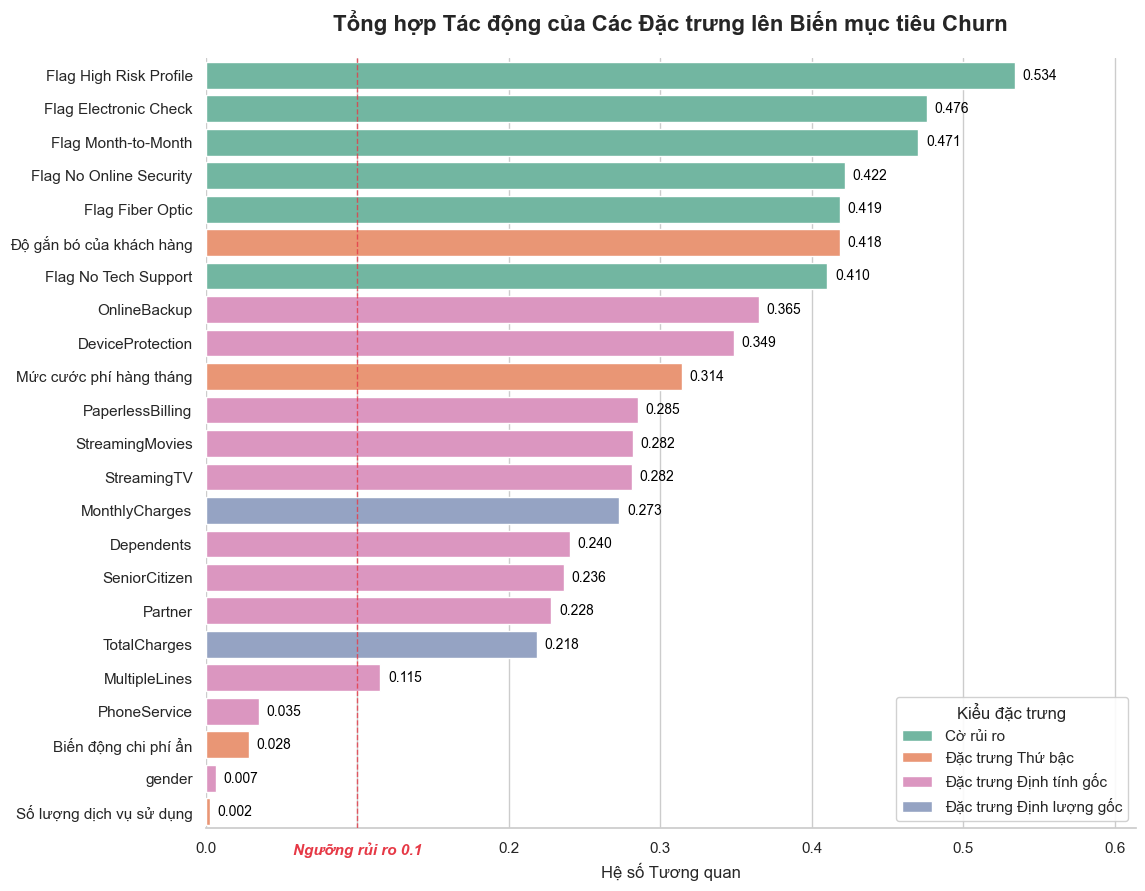

In [ ]:
master_df['Absolute_Power'] = master_df['Score'].abs()
master_df = master_df[master_df['Feature'] != 'ChurnFlag']
master_df = master_df.sort_values(by='Absolute_Power', ascending=False)

plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

bars = sns.barplot(data=master_df, y='Feature', x='Absolute_Power', 
                   hue='Method', dodge=False, 
                   palette = {
                    'Đặc trưng Định lượng gốc': '#8DA0CB',
                    'Đặc trưng Định tính gốc': '#E78AC3',
                    'Đặc trưng Thứ bậc': '#FC8D62',
                    'Cờ rủi ro': '#66C2A5'})

plt.title("Tổng hợp Tác động của Các Đặc trưng lên Biến mục tiêu Churn", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Hệ số Tương quan", fontsize=12)
plt.ylabel("")

for p in plt.gca().patches:
    val = p.get_width()
    if val > 0:
        plt.gca().annotate(f'{val:.3f}', 
                           (val + 0.005, p.get_y() + p.get_height() / 2.), 
                           ha='left', va='center', fontsize=10, color='black')

plt.legend(title="Kiểu đặc trưng", loc='lower right', framealpha=0.9)
plt.xlim(0, master_df['Absolute_Power'].max() + 0.08)

sns.despine(left=True)
plt.axvline(x=0.1, color='#e63946', linewidth=1.0, linestyle='--', alpha=0.8, zorder=5)

ax = plt.gca()

ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
ax.set_xticks(ticks)

tick_labels = ['0.0', 'Ngưỡng rủi ro 0.1', '0.2', '0.3', '0.4', '0.5', '0.6']
labels = ax.set_xticklabels(tick_labels)

labels[1].set_color('#e63946')
labels[1].set_fontweight('bold')
labels[1].set_fontstyle('italic')
plt.show()

**Nhận xét:**
- Nhóm *Risk Flags* chứng minh được tính ưu việt tuyệt đối khi chiếm trọn các vị trí top đầu. Trong đó, **Flag High Risk Profile** có ảnh hưởng mạnh nhất đến tỷ lệ rời bỏ với hệ số $0.534$, theo sát là các cờ liên quan đến thanh toán và loại hợp đồng.
- Dù không được sử dụng để tạo *Cờ rủi ro*, các dịch vụ như **OnlineBackup** $0.365$ hay **DeviceProtection** $0.349$ vẫn cho thấy mức độ ảnh hưởng đáng kể, qua đó cần được giữ lại để cung cấp thêm góc nhìn cho mô hình.
- Biến **Độ gắn bó của khách hàng** $0.418$ và Mức cước phí hàng tháng $0.314$ cho thấy tín hiệu dự đoán rất tốt, khẳng định việc nhóm hóa *binning* các dữ liệu liên tục là một quyết định chính xác.
- Các đặc trưng tự thiết lập như **Biến động chi phí ẩn** $0.028$, **Số lượng dịch vụ sử dụng** $0.002$ cùng với gender và PhoneService bị bỏ lại hoàn toàn phía sau *Ngưỡng rủi ro*. Điều này cho thấy giới tính, số lượng dịch vụ hay sự thay đổi chi phí phụ không tạo ra động lực thực sự cho quyết định hủy hợp đồng.

**Tổng kết:**
- Ta thực hiện xóa bỏ *Biến động chi phí ẩn* và *Số lượng dịch vụ sử dụng* vì hệ số tương quan tiệm cận 0 cho thấy sức dự báo không đáng kể, cùng với đó là các biến nhiễu như *gender*, *PhoneService*.
- Triệt tiêu Đa cộng tuyến: Xóa bỏ **TotalCharges** dù hệ số đạt $0.218$ vì về mặt toán học, đây chỉ là phép nhân của **Tenure** và **MonthlyCharges**. Việc giữ lại sẽ làm nhiễu trọng số của thuật toán.
- Ngoài ra, ta cũng thực hiện loại bỏ **customerID** vì đây là biến định danh, không có giá trị học thuật và **Churn* vì đã có *flag* tương ứng 
- Giữ lại toàn bộ các biến nằm trên *Ngưỡng 0.1*, ưu tiên *Cờ rủi ro* và *Các phân khúc thứ bậc* để đến với quá trình học máy *Machine Learning*
- Thực hiện loại bỏ tất cả đặc trưng định tính cấu tạo nên các *Cờ rủi ro* **flag_month_to_month**, **flag_electronic_check**, **flag_fiber_optic**, **flag_no_tech_support**, **flag_no_online_security**, **flag_high_risk_profile**, bao gồm các đặc trưng định tính gốc **PaymentMethod**, **Contract**, **OnlineSecurity**, **InternetService**, **TechSupport** 

In [ ]:
cols_to_drop = [
    'id',
    'Churn',
    'TotalCharges',
    'gender',
    'PhoneService',
    'spending_shift',
    'total_services',
    'PaymentMethod',
    'Contract',
    'OnlineSecurity',
    'InternetService',
    'TechSupport' 
]

df_model = df_train_copy.drop(columns=cols_to_drop).copy()

In [ ]:
df_model.head(20)

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,OnlineBackup,DeviceProtection,StreamingTV,StreamingMovies,PaperlessBilling,...,TotalServices,churn_flag,loyalty_tier,charge_segment,flag_month_to_month,flag_electronic_check,flag_fiber_optic,flag_no_tech_support,flag_no_online_security,flag_high_risk_profile
0,No,Yes,Yes,29,No,No,Yes,No,No,Yes,...,3,0,Familiar,Standard,0,0,0,0,0,0
1,No,Yes,Yes,58,No,Yes,No,Yes,No,No,...,4,0,Loyal,Standard,0,0,0,0,0,0
2,No,Yes,No,58,Yes,Yes,No,Yes,Yes,Yes,...,4,0,Loyal,Premium,1,1,1,1,1,1
3,No,No,No,1,No,No,No,No,No,Yes,...,0,1,Onboarding,Standard,1,1,1,1,1,1
4,No,No,No,1,No,No,No,No,No,Yes,...,0,1,Onboarding,Premium,1,1,1,1,1,1
5,No,Yes,Yes,1,No,No internet service,No internet service,No internet service,No internet service,Yes,...,0,0,Onboarding,Budget,1,0,0,0,0,0
6,No,Yes,Yes,24,No,No internet service,No internet service,No internet service,No internet service,No,...,0,0,Second Year,Budget,1,0,0,0,0,0
7,No,Yes,No,72,Yes,Yes,Yes,Yes,Yes,No,...,7,0,Loyal,Premium,0,1,0,0,0,0
8,Yes,No,No,1,Yes,No,Yes,No,No,Yes,...,2,1,Onboarding,Premium,1,1,1,1,1,1
9,No,No,No,55,No,Yes,No,Yes,Yes,Yes,...,4,0,Loyal,Premium,1,1,1,1,0,1


In [ ]:

df_model.to_csv('model.csv', index=False)